# LTA (Lipoteichoic Acid) Raman Spectrum Analysis Pipeline

**Project:** SERS-based Nano-biosensor for Bacterial Sepsis Diagnosis  
**Institute:** IIT Jodhpur  
**Molecule:** Lipoteichoic Acid (LTA) — Gram-positive bacterial biomarker  
**Date:** 2026-03-17  

---

## Objectives
1. Process all experimental Raman spectra automatically
2. Rank spectra by quality score (SNR, FWHM, peak intensity)
3. Identify the best experimental spectrum
4. Extract LTA Raman fingerprint peaks
5. Compare experimental peaks with DFT simulated Raman spectrum
6. Validate peak assignments with functional group literature
7. Generate all publication-ready figures and scientific report

---

## Workflow Phases
| Phase | Description |
|---|---|
| 1 | Data Discovery |
| 2 | Spectral Preprocessing |
| 3 | Quality Metric Computation |
| 4 | Spectrum Ranking |
| 5 | Visualization |
| 6 | Best Spectrum Extraction |
| 7 | Simulation Comparison |
| 8 | Validation |
| 9 | Peak Assignment |
| 10 | Reporting |


In [1]:
import os, glob, re, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.signal import savgol_filter, find_peaks, peak_widths
from scipy.stats import pearsonr
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['font.size'] = 10
plt.style.use('seaborn-v0_8-whitegrid')

print("=" * 60)
print("CELL 2 — Library Import")
print("=" * 60)
print("What was done:")
print("  Imported all required scientific libraries.")
print()
print("Libraries loaded:")
print(f"  numpy      {np.__version__}")
print(f"  pandas     {pd.__version__}")
print(f"  matplotlib {matplotlib.__version__}")
print()
print("Status: ✅ All libraries loaded successfully.")


CELL 2 — Library Import
What was done:
  Imported all required scientific libraries.

Libraries loaded:
  numpy      2.4.3
  pandas     3.0.1
  matplotlib 3.10.8

Status: ✅ All libraries loaded successfully.


In [2]:
# -- Paths -----------------------------------------------------
DATA_FOLDER     = "."
SIM_FILE_CANDIDATES = [
    "simdata.xlsx",
    "LTA-sim-data.xlsx",
    os.path.join("All_Excel_Files", "simdata.xlsx"),
    os.path.join("All_Excel_Files", "LTA-sim-data.xlsx"),
]
SIM_FILE = next((p for p in SIM_FILE_CANDIDATES if os.path.exists(p)), SIM_FILE_CANDIDATES[0])
OUTPUT_FOLDER   = "LTA_outputs"
FIG_FOLDER      = os.path.join(OUTPUT_FOLDER, "figures")
DATA_OUT_FOLDER = os.path.join(OUTPUT_FOLDER, "data")
REPORT_FOLDER   = os.path.join(OUTPUT_FOLDER, "report")

for folder in [FIG_FOLDER, DATA_OUT_FOLDER, REPORT_FOLDER]:
    os.makedirs(folder, exist_ok=True)

# -- Spectral range ---------------------------------------------
SHIFT_MIN, SHIFT_MAX = 200, 3000

# -- Baseline correction (ALS) ----------------------------------
APPLY_BASELINE  = True
BASELINE_LAMBDA = 1e5
BASELINE_P      = 0.01
BASELINE_NITER  = 10

# -- Savitzky-Golay smoothing -----------------------------------
SG_WINDOW, SG_POLY = 11, 3

# -- Peak detection ---------------------------------------------
PEAK_DISTANCE        = 10
PEAK_PROMINENCE      = 0.05

# -- SNR noise region -------------------------------------------
NOISE_MIN, NOISE_MAX = 1800, 1900

# -- Quality score weights --------------------------------------
W_SNR, W_FWHM, W_INTENSITY = 0.5, 0.3, 0.2

# -- DFT parameters ---------------------------------------------
DFT_SCALE       = 0.98
BROAD_FWHM      = 10       # cm-1 Gaussian broadening

# -- Peak matching -----------------------------------------------
MATCH_TOLERANCE = 15       # cm-1

# -- LTA Key Literature Peaks and Assignments --------------------
LTA_PEAKS = {
    720:  "P-O-C vibration (phosphodiester)",
    735:  "P-O-C vibration (phosphate backbone)",
    870:  "C-O-C ring stretch (glycerol)",
    890:  "C-O-C ring stretch",
    1000: "C-C skeletal vibration",
    1005: "C-C ring breathing",
    1085: "PO₂⁻ symmetric stretch",
    1090: "PO₂⁻ stretch (phosphate)",
    1120: "C-O stretch (ether)",
    1130: "C-O-C symmetric stretch",
    1290: "CH₂ twisting",
    1300: "CH₂ twisting",
    1450: "CH₂ bending / scissoring",
    1460: "CH₂ deformation",
    1650: "C=O stretch / amide I",
    1660: "C=O amide vibration",
}

print("=" * 60)
print("CELL 3 — Configuration and Output Folder Setup")
print("=" * 60)
print("What was done:")
print("  Set all analysis parameters.")
print("  Created output folder structure.")
print()
print("Output folders created:")
for f in [FIG_FOLDER, DATA_OUT_FOLDER, REPORT_FOLDER]:
    print(f"  {f}/")
print()
print("Key Parameters:")
print(f"  Analysis range   : {SHIFT_MIN} – {SHIFT_MAX} cm⁻¹")
if APPLY_BASELINE:
    print(f"  Baseline      : ALS (lambda={BASELINE_LAMBDA:.0e}, p={BASELINE_P}, niter={BASELINE_NITER})")
else:
    print("  Baseline      : disabled")
print(f"  SG smoothing     : window={SG_WINDOW}, polyorder={SG_POLY}")
print(f"  Noise region     : {NOISE_MIN} – {NOISE_MAX} cm⁻¹")
print(f"  DFT scale factor : {DFT_SCALE}")
print(f"  Broadening FWHM  : {BROAD_FWHM} cm⁻¹")
print(f"  Match tolerance  : {MATCH_TOLERANCE} cm⁻¹")
print(f"  Simulation file  : {SIM_FILE}")
print()
print("Status: ✅ Configuration complete.")


CELL 3 — Configuration and Output Folder Setup
What was done:
  Set all analysis parameters.
  Created output folder structure.

Output folders created:
  LTA_outputs\figures/
  LTA_outputs\data/
  LTA_outputs\report/

Key Parameters:
  Analysis range   : 200 – 3000 cm⁻¹
  Baseline      : ALS (lambda=1e+05, p=0.01, niter=10)
  SG smoothing     : window=11, polyorder=3
  Noise region     : 1800 – 1900 cm⁻¹
  DFT scale factor : 0.98
  Broadening FWHM  : 10 cm⁻¹
  Match tolerance  : 15 cm⁻¹
  Simulation file  : LTA-sim-data.xlsx

Status: ✅ Configuration complete.


In [3]:
all_files_raw = glob.glob(os.path.join(DATA_FOLDER, "**", "*.xlsx"), recursive=True)
all_files_raw = [f for f in all_files_raw if "simdata" not in os.path.basename(f).lower()]

file_records = []
for filepath in all_files_raw:
    fname = os.path.basename(filepath)
    sec_m   = re.search(r'sec-(\d+)', fname)
    power_m = re.search(r'power-(\d+)', fname)
    rep_m   = re.search(r'i-\d+_(\d+)', fname)
    if sec_m and power_m:
        file_records.append({
            "filepath" : filepath,
            "filename" : fname,
            "sec"      : int(sec_m.group(1)),
            "power"    : int(power_m.group(1)),
            "replicate": int(rep_m.group(1)) if rep_m else 1,
        })

file_df = pd.DataFrame(file_records)
unique_sec   = sorted(file_df['sec'].unique())
unique_power = sorted(file_df['power'].unique())

print("=" * 60)
print("CELL 4 — File Discovery")
print("=" * 60)
print("What was done:")
print("  Recursively searched for all .xlsx files.")
print("  Parsed integration time and laser power from filenames.")
print()
print(f"Total experimental files found : {len(file_records)}")
print(f"Integration times (sec)        : {unique_sec}")
print(f"Laser powers (%)               : {unique_power}")
print()
print("Sample files (first 5):")
for r in file_records[:5]:
    print(f"  {r['filename']}  →  sec={r['sec']}, power={r['power']}, rep={r['replicate']}")
print()
print("Status: ✅ File discovery complete.")


CELL 4 — File Discovery
What was done:
  Recursively searched for all .xlsx files.
  Parsed integration time and laser power from filenames.

Total experimental files found : 136
Integration times (sec)        : [np.int64(10), np.int64(15), np.int64(20), np.int64(25)]
Laser powers (%)               : [np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50), np.int64(55), np.int64(60), np.int64(65), np.int64(70), np.int64(75), np.int64(80)]

Sample files (first 5):
  sec-10_power-10_i-2.xlsx  →  sec=10, power=10, rep=1
  sec-10_power-10_i-2_1.xlsx  →  sec=10, power=10, rep=1
  sec-10_power-10_i-2_2.xlsx  →  sec=10, power=10, rep=2
  sec-10_power-10_i-2_3.xlsx  →  sec=10, power=10, rep=3
  sec-10_power-10_i-2_4.xlsx  →  sec=10, power=10, rep=4

Status: ✅ File discovery complete.


In [4]:
def als_baseline(y, lam=1e5, p=0.01, niter=10):
    """Asymmetric least squares baseline correction."""
    y = np.asarray(y, dtype=float)
    if y.ndim != 1 or len(y) < 3:
        return np.zeros_like(y, dtype=float)

    length = len(y)
    d_mat = diags([1.0, -2.0, 1.0], [0, 1, 2], shape=(length - 2, length))
    weights = np.ones(length, dtype=float)

    for _ in range(int(niter)):
        w_mat = diags(weights, 0, shape=(length, length))
        z_mat = w_mat + lam * (d_mat.T @ d_mat)
        baseline = spsolve(z_mat, weights * y)
        weights = p * (y > baseline) + (1 - p) * (y <= baseline)

    return np.asarray(baseline, dtype=float)


def preprocess_spectrum(filepath):
    """Load, clean, baseline-correct, smooth, normalize a Raman spectrum."""
    try:
        df_raw = pd.read_excel(filepath, header=0)

        # Prefer explicit Raman columns when present in exported instrument files.
        col_pairs = list(zip(df_raw.columns, [str(c).strip().lower() for c in df_raw.columns]))
        shift_col = next((c for c, n in col_pairs if ("raman shift" in n) or (n == "shift")), None)
        int_col = next((c for c, n in col_pairs if ("dark subtracted" in n) or ("intensity" in n)), None)

        if shift_col is not None and int_col is not None:
            df = df_raw[[shift_col, int_col]].copy()
        else:
            # Fallback: choose first two mostly numeric columns.
            numeric_candidates = []
            for col in df_raw.columns:
                vals = pd.to_numeric(df_raw[col], errors='coerce')
                if vals.notna().sum() >= 50:
                    numeric_candidates.append(col)
            if len(numeric_candidates) < 2:
                return None, None
            df = df_raw[numeric_candidates[:2]].copy()

        df.columns = ['shift', 'intensity']
        df = df.dropna()
        df['shift']     = pd.to_numeric(df['shift'],     errors='coerce')
        df['intensity'] = pd.to_numeric(df['intensity'], errors='coerce')
        df = df.dropna()
        if len(df) < 100:
            return None, None
        df = df.sort_values('shift').reset_index(drop=True)
        mask = (df['shift'] >= SHIFT_MIN) & (df['shift'] <= SHIFT_MAX)
        df = df[mask].reset_index(drop=True)
        if len(df) < 50:
            return None, None
        x = df['shift'].values.astype(float)
        y = df['intensity'].values.astype(float)

        if APPLY_BASELINE:
            try:
                baseline = als_baseline(
                    y,
                    lam=BASELINE_LAMBDA,
                    p=BASELINE_P,
                    niter=BASELINE_NITER,
                )
                y = y - baseline
            except Exception:
                pass

        win = SG_WINDOW if len(y) >= SG_WINDOW else (len(y) // 2) * 2 - 1
        win = max(win, 5)
        y_smooth = savgol_filter(y, window_length=win, polyorder=SG_POLY)
        y_smooth = np.clip(y_smooth, 0, None)
        ymax = np.max(y_smooth)
        if ymax > 0:
            y_smooth = y_smooth / ymax
        return x, y_smooth
    except Exception:
        return None, None


def calculate_metrics(shift, intensity):
    """Compute SNR, FWHM, max intensity, quality score."""
    result = {'snr': np.nan, 'fwhm': np.nan,
              'max_intensity': np.nan, 'score': np.nan, 'n_peaks': 0}
    try:
        prom_thresh = PEAK_PROMINENCE * np.max(intensity)
        peaks, props = find_peaks(intensity,
                                  distance=PEAK_DISTANCE,
                                  prominence=prom_thresh)
        result['n_peaks'] = len(peaks)
        if len(peaks) == 0:
            return result

        heights = intensity[peaks]
        main_idx = peaks[np.argmax(heights)]
        signal   = intensity[main_idx]

        noise_mask = (shift > NOISE_MIN) & (shift < NOISE_MAX)
        if noise_mask.sum() > 5:
            noise_std = np.std(intensity[noise_mask])
        else:
            noise_std = np.std(intensity[int(len(intensity)*0.95):])
        noise_std = max(noise_std, 1e-6)

        snr  = signal / noise_std

        widths, _, _, _ = peak_widths(intensity, [main_idx], rel_height=0.5)
        step = np.mean(np.diff(shift))
        fwhm = widths[0] * step
        fwhm = max(fwhm, 1e-3)

        max_int = np.max(intensity)
        score   = W_SNR * snr + W_FWHM * (1.0 / fwhm) + W_INTENSITY * max_int

        result.update({'snr': snr, 'fwhm': fwhm,
                       'max_intensity': max_int, 'score': score})
    except Exception:
        pass
    return result


def gaussian_broaden(sim_shifts, sim_activities, grid, fwhm_val=BROAD_FWHM):
    """Sum Gaussians to build broadened simulated spectrum."""
    sigma  = fwhm_val / (2 * np.sqrt(2 * np.log(2)))
    result = np.zeros_like(grid, dtype=float)
    for x0, a in zip(sim_shifts, sim_activities):
        result += a * np.exp(-((grid - x0) ** 2) / (2 * sigma ** 2))
    if result.max() > 0:
        result /= result.max()
    return result


print("=" * 60)
print("CELL 5 — Preprocessing & Metric Functions Defined")
print("=" * 60)
print("What was done:")
print("  Defined als_baseline()        — ALS baseline subtraction.")
print("  Defined preprocess_spectrum() — load, baseline-correct, smooth, normalize.")
print("  Defined calculate_metrics()   — SNR, FWHM, score.")
print("  Defined gaussian_broaden()    — DFT spectral broadening.")
print()
print("Processing details:")
if APPLY_BASELINE:
    print(f"  Baseline      : ALS (lambda={BASELINE_LAMBDA:.0e}, p={BASELINE_P}, niter={BASELINE_NITER})")
else:
    print("  Baseline      : disabled")
print(f"  Smoothing     : Savitzky-Golay (window={SG_WINDOW}, poly={SG_POLY})")
print(f"  Normalization : max intensity → 1.0")
print(f"  SNR region    : {NOISE_MIN}–{NOISE_MAX} cm⁻¹")
print(f"  Quality score : {W_SNR}×SNR + {W_FWHM}×(1/FWHM) + {W_INTENSITY}×Intensity")
print()
print("Status: ✅ Functions ready.")


CELL 5 — Preprocessing & Metric Functions Defined
What was done:
  Defined als_baseline()        — ALS baseline subtraction.
  Defined preprocess_spectrum() — load, baseline-correct, smooth, normalize.
  Defined calculate_metrics()   — SNR, FWHM, score.
  Defined gaussian_broaden()    — DFT spectral broadening.

Processing details:
  Baseline      : ALS (lambda=1e+05, p=0.01, niter=10)
  Smoothing     : Savitzky-Golay (window=11, poly=3)
  Normalization : max intensity → 1.0
  SNR region    : 1800–1900 cm⁻¹
  Quality score : 0.5×SNR + 0.3×(1/FWHM) + 0.2×Intensity

Status: ✅ Functions ready.


In [5]:
print("=" * 60)
print("CELL 6 — Processing All Spectra")
print("=" * 60)
print("What is being done:")
print("  Loading, preprocessing, and scoring every spectrum file.")
print()

results   = []
failed    = []

for _, row in file_df.iterrows():
    fp = row['filepath']
    x, y = preprocess_spectrum(fp)
    if x is None:
        failed.append(fp)
        continue
    metrics = calculate_metrics(x, y)
    results.append({
        'filepath'     : fp,
        'filename'     : row['filename'],
        'sec'          : row['sec'],
        'power'        : row['power'],
        'replicate'    : row['replicate'],
        'snr'          : metrics['snr'],
        'fwhm'         : metrics['fwhm'],
        'max_intensity': metrics['max_intensity'],
        'score'        : metrics['score'],
        'n_peaks'      : metrics['n_peaks'],
    })

ranked_df = pd.DataFrame(results).dropna(subset=['score'])
ranked_df = ranked_df.sort_values('score', ascending=False).reset_index(drop=True)
ranked_df.to_csv(os.path.join(DATA_OUT_FOLDER, "ranked_spectra_table.csv"), index=False)

best = ranked_df.iloc[0]

print(f"Total files attempted  : {len(file_df)}")
print(f"Successfully processed : {len(results)}")
print(f"Failed / skipped       : {len(failed)}")
if failed:
    for f in failed: print(f"  SKIPPED: {os.path.basename(f)}")
print()
print("Top 5 spectra by Quality Score:")
print(ranked_df[['filename','sec','power','snr','fwhm','score']].head(5).to_string(index=False))
print()
print(f"Best spectrum  : {best['filename']}")
print(f"  Integration  : {best['sec']} sec")
print(f"  Laser power  : {best['power']} %")
print(f"  SNR          : {best['snr']:.2f}")
print(f"  FWHM         : {best['fwhm']:.2f} cm⁻¹")
print(f"  Score        : {best['score']:.4f}")
print()
print("Saved: ranked_spectra_table.csv")
print("Status: ✅ All spectra ranked.")


CELL 6 — Processing All Spectra
What is being done:
  Loading, preprocessing, and scoring every spectrum file.

Total files attempted  : 136
Successfully processed : 136
Failed / skipped       : 0

Top 5 spectra by Quality Score:
                  filename  sec  power        snr     fwhm     score
sec-20_power-40_i-2_2.xlsx   20     40 139.032366 9.134061 69.749027
sec-20_power-40_i-2_2.xlsx   20     40 139.032366 9.134061 69.749027
sec-20_power-30_i-2_1.xlsx   20     30 109.340277 9.147405 54.902934
  sec-20_power-30_i-2.xlsx   20     30 109.340277 9.147405 54.902934
sec-20_power-20_i-2_2.xlsx   20     20 102.430512 9.147945 51.448050

Best spectrum  : sec-20_power-40_i-2_2.xlsx
  Integration  : 20 sec
  Laser power  : 40 %
  SNR          : 139.03
  FWHM         : 9.13 cm⁻¹
  Score        : 69.7490

Saved: ranked_spectra_table.csv
Status: ✅ All spectra ranked.


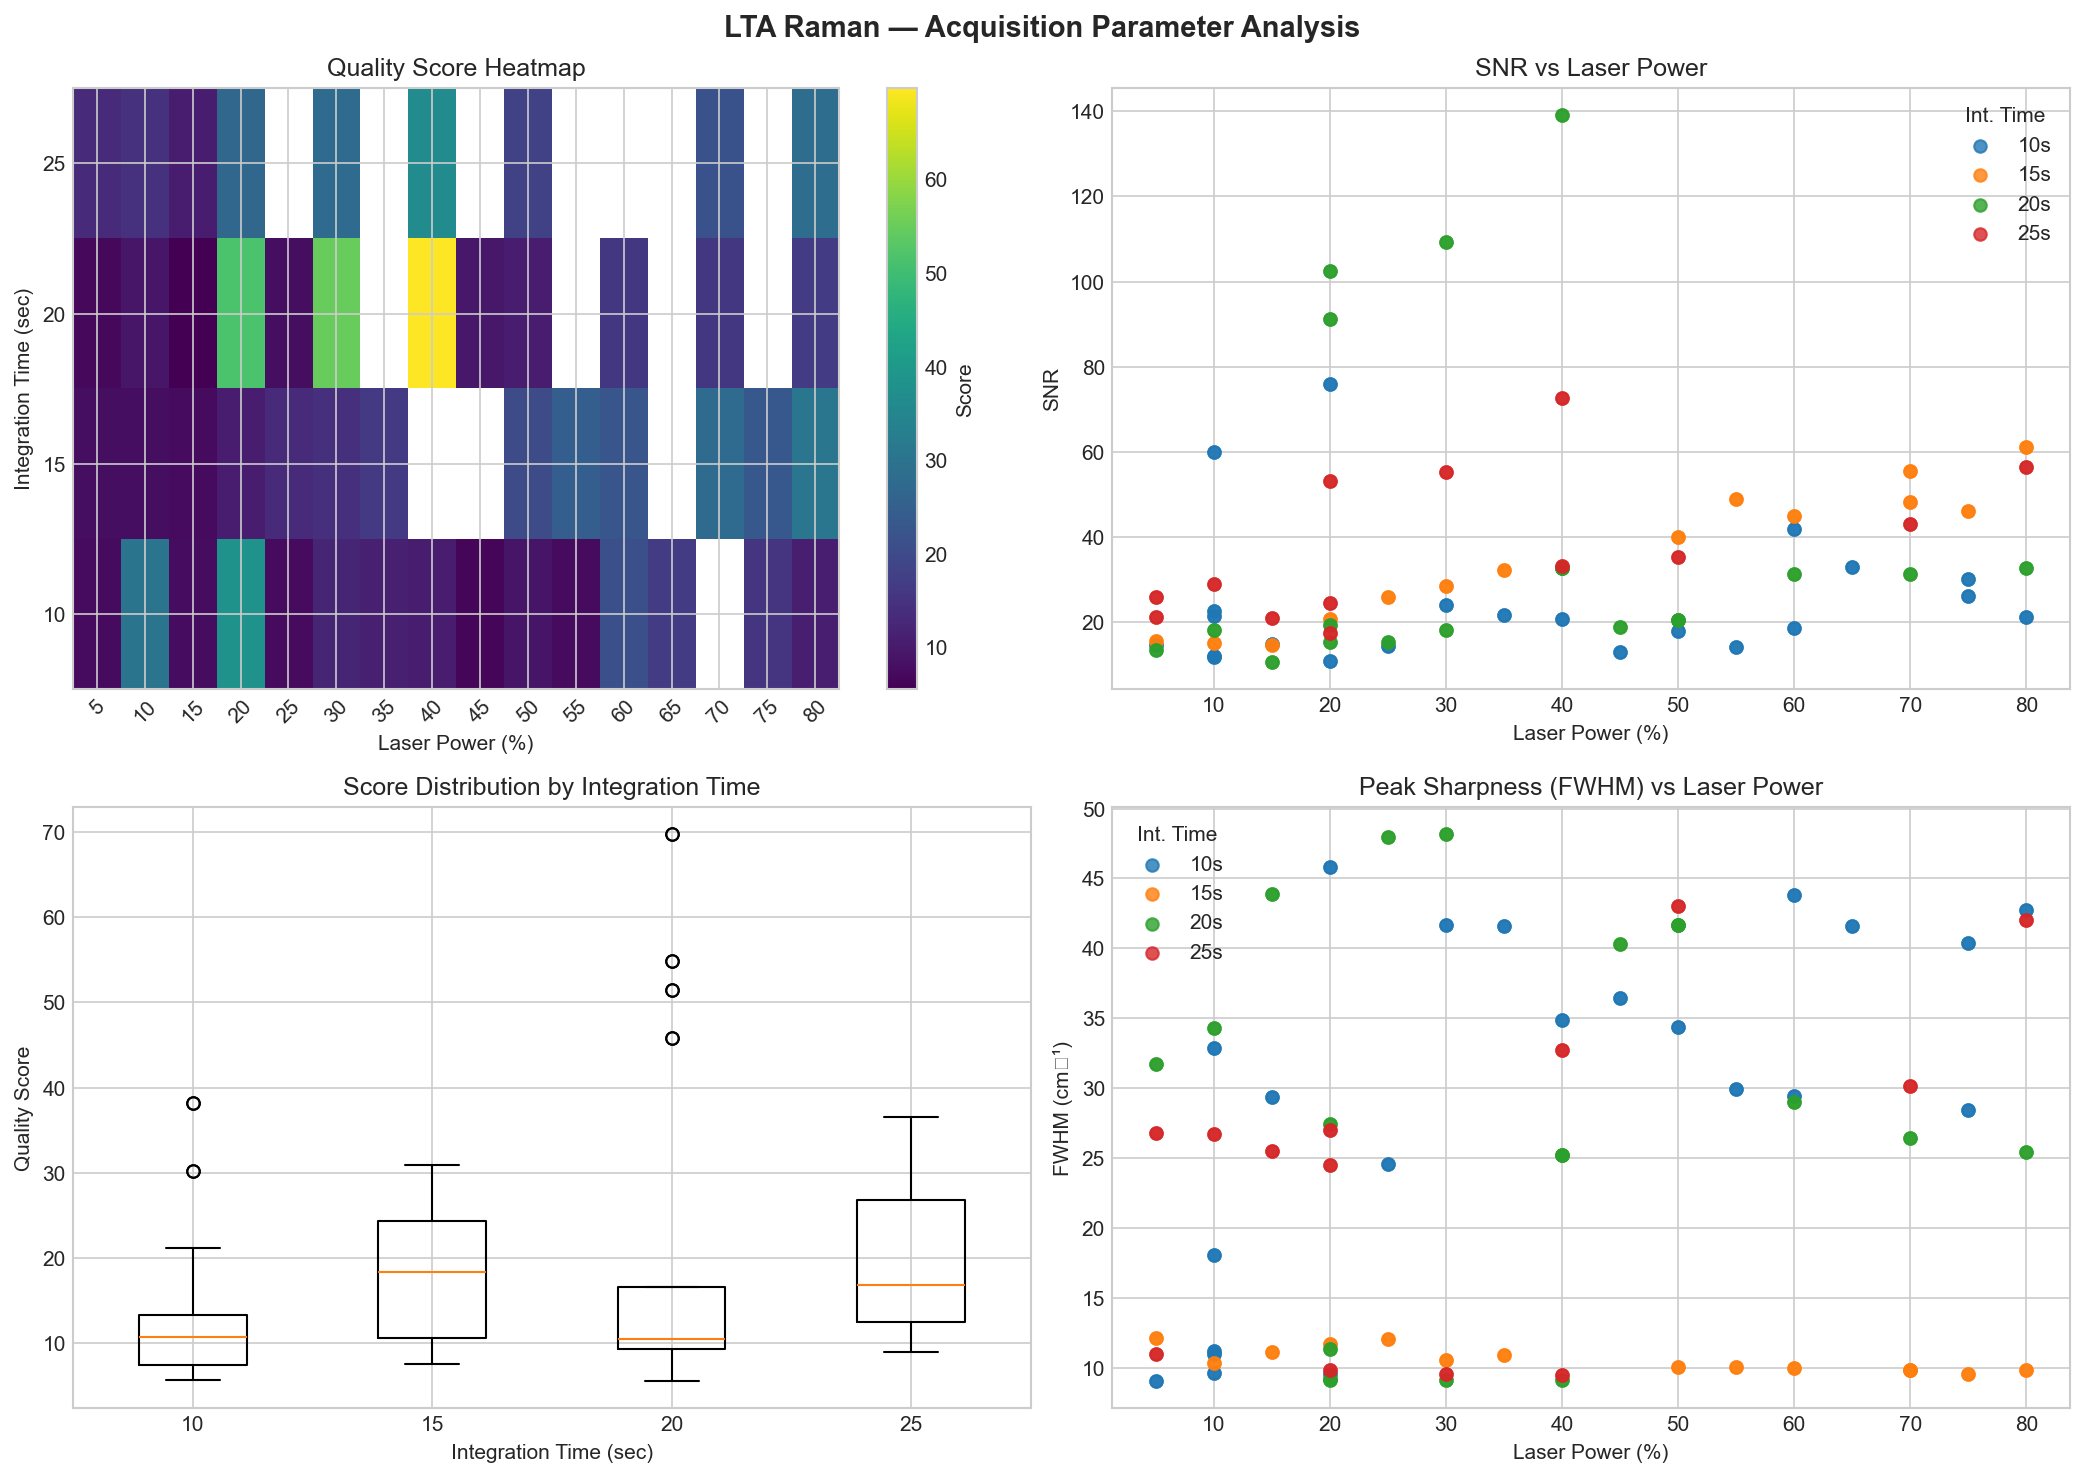

CELL 7 — Figure 1: Acquisition Parameter Analysis
What was done:
  Panel 1: Heatmap of quality score vs (integration time × laser power).
  Panel 2: SNR scatter vs laser power, colour-coded by integration time.
  Panel 3: Box plot of quality scores per integration time.
  Panel 4: FWHM (peak sharpness) vs laser power.

Best region from heatmap : sec=20, power=40%
Saved: fig01_acquisition_parameter_analysis.png
Status: ✅ Figure 1 saved.


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LTA Raman — Acquisition Parameter Analysis', fontsize=14, fontweight='bold')

# Heatmap
pivot = ranked_df.pivot_table(values='score', index='sec', columns='power', aggfunc='max')
im = axes[0,0].imshow(pivot.values, aspect='auto', cmap='viridis',
                      origin='lower')
axes[0,0].set_xticks(range(len(pivot.columns)))
axes[0,0].set_xticklabels(pivot.columns, rotation=45)
axes[0,0].set_yticks(range(len(pivot.index)))
axes[0,0].set_yticklabels(pivot.index)
axes[0,0].set_xlabel('Laser Power (%)')
axes[0,0].set_ylabel('Integration Time (sec)')
axes[0,0].set_title('Quality Score Heatmap')
plt.colorbar(im, ax=axes[0,0], label='Score')

# SNR vs Power
for s in sorted(ranked_df['sec'].unique()):
    sub = ranked_df[ranked_df['sec'] == s]
    axes[0,1].scatter(sub['power'], sub['snr'], label=f'{s}s', alpha=0.8)
axes[0,1].set_xlabel('Laser Power (%)')
axes[0,1].set_ylabel('SNR')
axes[0,1].set_title('SNR vs Laser Power')
axes[0,1].legend(title='Int. Time')

# Score by Integration Time
data_box = [ranked_df[ranked_df['sec']==s]['score'].dropna().values
            for s in sorted(ranked_df['sec'].unique())]
axes[1,0].boxplot(data_box, labels=sorted(ranked_df['sec'].unique()))
axes[1,0].set_xlabel('Integration Time (sec)')
axes[1,0].set_ylabel('Quality Score')
axes[1,0].set_title('Score Distribution by Integration Time')

# FWHM vs Power
for s in sorted(ranked_df['sec'].unique()):
    sub = ranked_df[ranked_df['sec'] == s]
    axes[1,1].scatter(sub['power'], sub['fwhm'], label=f'{s}s', alpha=0.8)
axes[1,1].set_xlabel('Laser Power (%)')
axes[1,1].set_ylabel('FWHM (cm⁻¹)')
axes[1,1].set_title('Peak Sharpness (FWHM) vs Laser Power')
axes[1,1].legend(title='Int. Time')

plt.tight_layout()
fig_path = os.path.join(FIG_FOLDER, "fig01_acquisition_parameter_analysis.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("CELL 7 — Figure 1: Acquisition Parameter Analysis")
print("=" * 60)
print("What was done:")
print("  Panel 1: Heatmap of quality score vs (integration time × laser power).")
print("  Panel 2: SNR scatter vs laser power, colour-coded by integration time.")
print("  Panel 3: Box plot of quality scores per integration time.")
print("  Panel 4: FWHM (peak sharpness) vs laser power.")
print()
pivot_best = pivot.stack().idxmax()
print(f"Best region from heatmap : sec={pivot_best[0]}, power={pivot_best[1]}%")
print(f"Saved: fig01_acquisition_parameter_analysis.png")
print("Status: ✅ Figure 1 saved.")


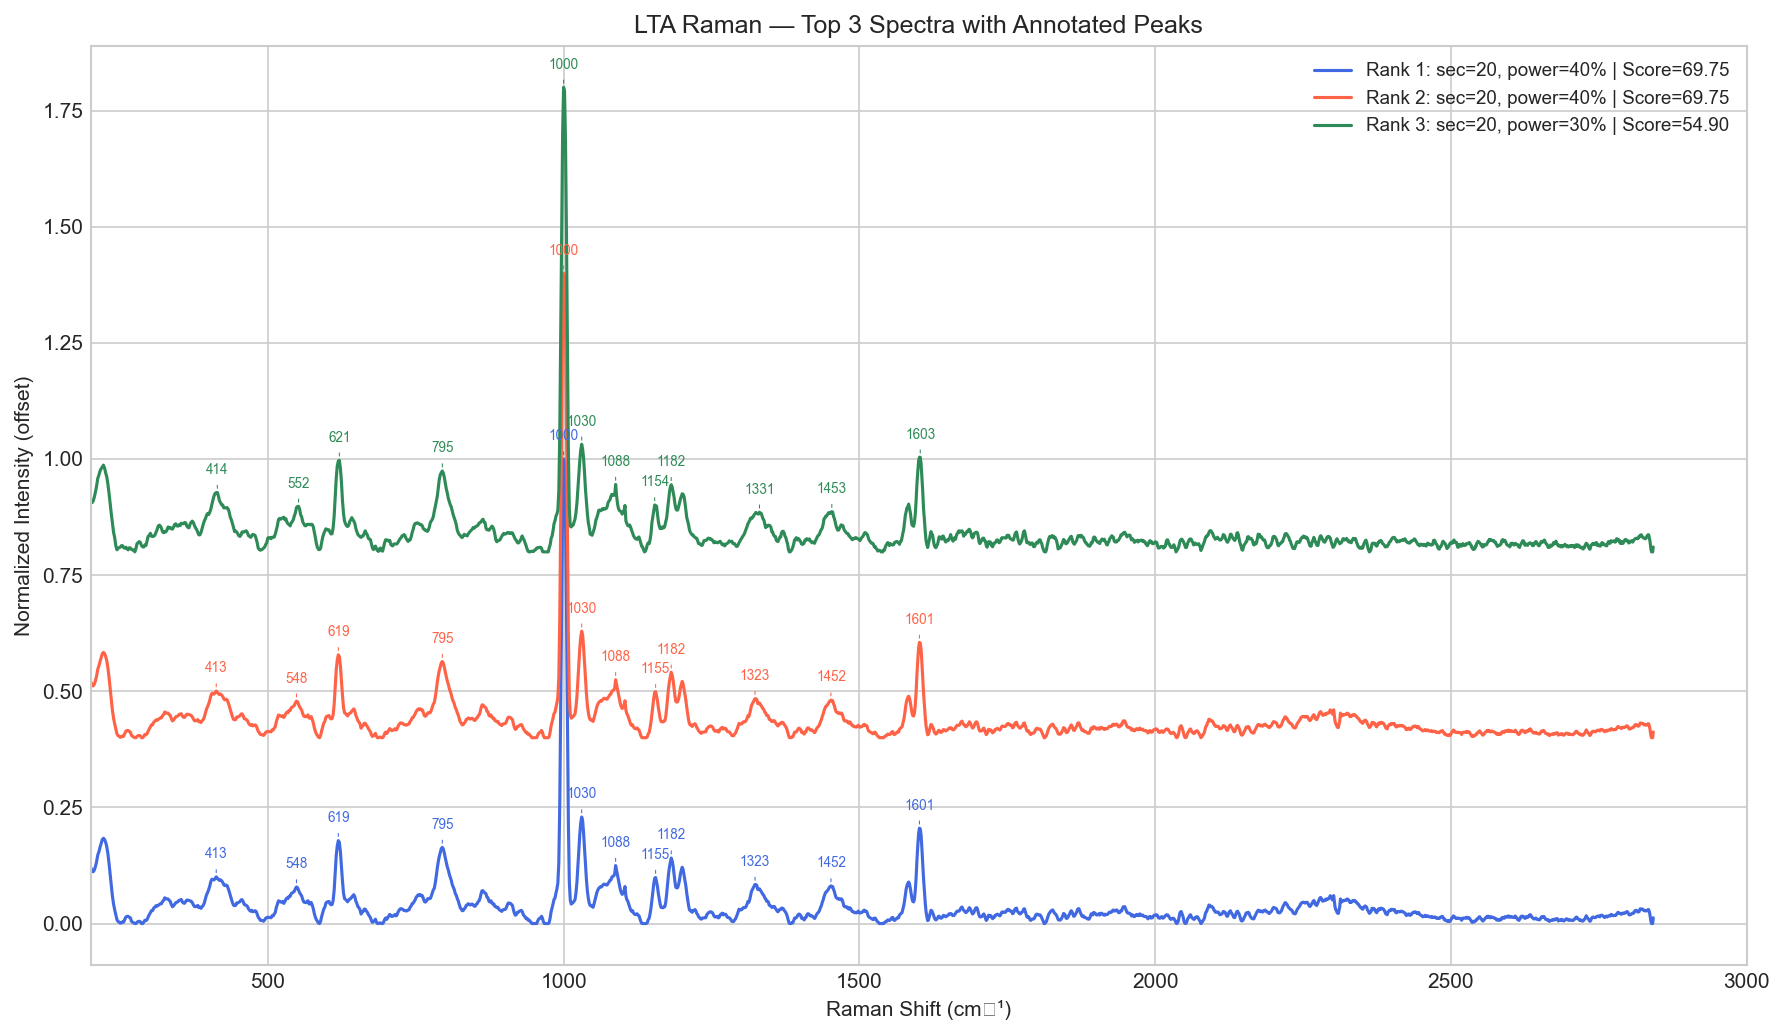

CELL 8 — Figure 2: Best Spectra Annotated Overlay
What was done:
  Loaded top 3 ranked spectra.
  Plotted with vertical offsets (waterfall-style).
  Annotated detected peak positions in cm⁻¹.

Top 3 spectra:
  Rank 1: sec-20_power-40_i-2_2.xlsx  sec=20, power=40%  score=69.7490
  Rank 2: sec-20_power-40_i-2_2.xlsx  sec=20, power=40%  score=69.7490
  Rank 3: sec-20_power-30_i-2_1.xlsx  sec=20, power=30%  score=54.9029

Saved: fig02_best_spectra_annotated.png
Status: ✅ Figure 2 saved.


In [7]:
top3 = ranked_df.head(3)
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['royalblue', 'tomato', 'seagreen']
offset_step = 0.4

for i, (_, row) in enumerate(top3.iterrows()):
    x, y = preprocess_spectrum(row['filepath'])
    if x is None: continue
    offset = i * offset_step
    ax.plot(x, y + offset, color=colors[i], lw=1.5,
            label=f"Rank {i+1}: sec={row['sec']}, power={row['power']}% | Score={row['score']:.2f}")
    peaks, _ = find_peaks(y, distance=PEAK_DISTANCE,
                          prominence=PEAK_PROMINENCE * np.max(y))
    for pk in peaks:
        if 300 < x[pk] < 1800:
            ax.annotate(f"{x[pk]:.0f}",
                        xy=(x[pk], y[pk] + offset),
                        xytext=(x[pk], y[pk] + offset + 0.04),
                        fontsize=6.5, ha='center', color=colors[i],
                        arrowprops=dict(arrowstyle='-', lw=0.5, color=colors[i]))

ax.set_xlabel('Raman Shift (cm⁻¹)')
ax.set_ylabel('Normalized Intensity (offset)')
ax.set_title('LTA Raman — Top 3 Spectra with Annotated Peaks')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(SHIFT_MIN, SHIFT_MAX)
plt.tight_layout()
fig_path = os.path.join(FIG_FOLDER, "fig02_best_spectra_annotated.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("CELL 8 — Figure 2: Best Spectra Annotated Overlay")
print("=" * 60)
print("What was done:")
print("  Loaded top 3 ranked spectra.")
print("  Plotted with vertical offsets (waterfall-style).")
print("  Annotated detected peak positions in cm⁻¹.")
print()
print("Top 3 spectra:")
for i, (_, row) in enumerate(top3.iterrows()):
    print(f"  Rank {i+1}: {row['filename']}  sec={row['sec']}, power={row['power']}%  score={row['score']:.4f}")
print()
print("Saved: fig02_best_spectra_annotated.png")
print("Status: ✅ Figure 2 saved.")


In [8]:
best_x, best_y = preprocess_spectrum(best['filepath'])

proc_df = pd.DataFrame({'raman_shift': best_x, 'intensity': best_y})
proc_path = os.path.join(DATA_OUT_FOLDER, "processed_best_spectrum.csv")
proc_df.to_csv(proc_path, index=False)

# Strict peak detection on best spectrum
peaks_strict, props_strict = find_peaks(
    best_y,
    distance=15,
    prominence=0.1 * np.max(best_y)
)
peak_df = pd.DataFrame({
    'raman_shift': best_x[peaks_strict],
    'intensity'  : best_y[peaks_strict],
})
peak_df = peak_df[(peak_df['raman_shift'] > 300) & (peak_df['raman_shift'] < 1800)]
peak_df = peak_df.sort_values('raman_shift').reset_index(drop=True)
peak_df.to_csv(os.path.join(DATA_OUT_FOLDER, "best_spectrum_peaks.csv"), index=False)

print("=" * 60)
print("CELL 9 — Best Spectrum Export")
print("=" * 60)
print("What was done:")
print("  Preprocessed and saved best spectrum as CSV.")
print("  Applied strict peak detection (prominence > 10% max).")
print("  Saved experimental peak list.")
print()
print(f"Best spectrum file  : {best['filename']}")
print(f"Data points saved   : {len(proc_df)}")
print(f"Shift range         : {best_x.min():.1f} – {best_x.max():.1f} cm⁻¹")
print()
print("Detected Peaks (experimental fingerprint):")
print(peak_df.to_string(index=False))
print()
print("Saved: processed_best_spectrum.csv")
print("Saved: best_spectrum_peaks.csv")
print("Status: ✅ Best spectrum exported.")


CELL 9 — Best Spectrum Export
What was done:
  Preprocessed and saved best spectrum as CSV.
  Applied strict peak detection (prominence > 10% max).
  Saved experimental peak list.

Best spectrum file  : sec-20_power-40_i-2_2.xlsx
Data points saved   : 1922
Shift range         : 200.8 – 2841.9 cm⁻¹

Detected Peaks (experimental fingerprint):
 raman_shift  intensity
  412.537588   0.100592
  618.951067   0.178483
  794.776904   0.163979
  999.792816   1.000000
 1030.389541   0.229372
 1181.775458   0.140970
 1601.347264   0.205267

Saved: processed_best_spectrum.csv
Saved: best_spectrum_peaks.csv
Status: ✅ Best spectrum exported.


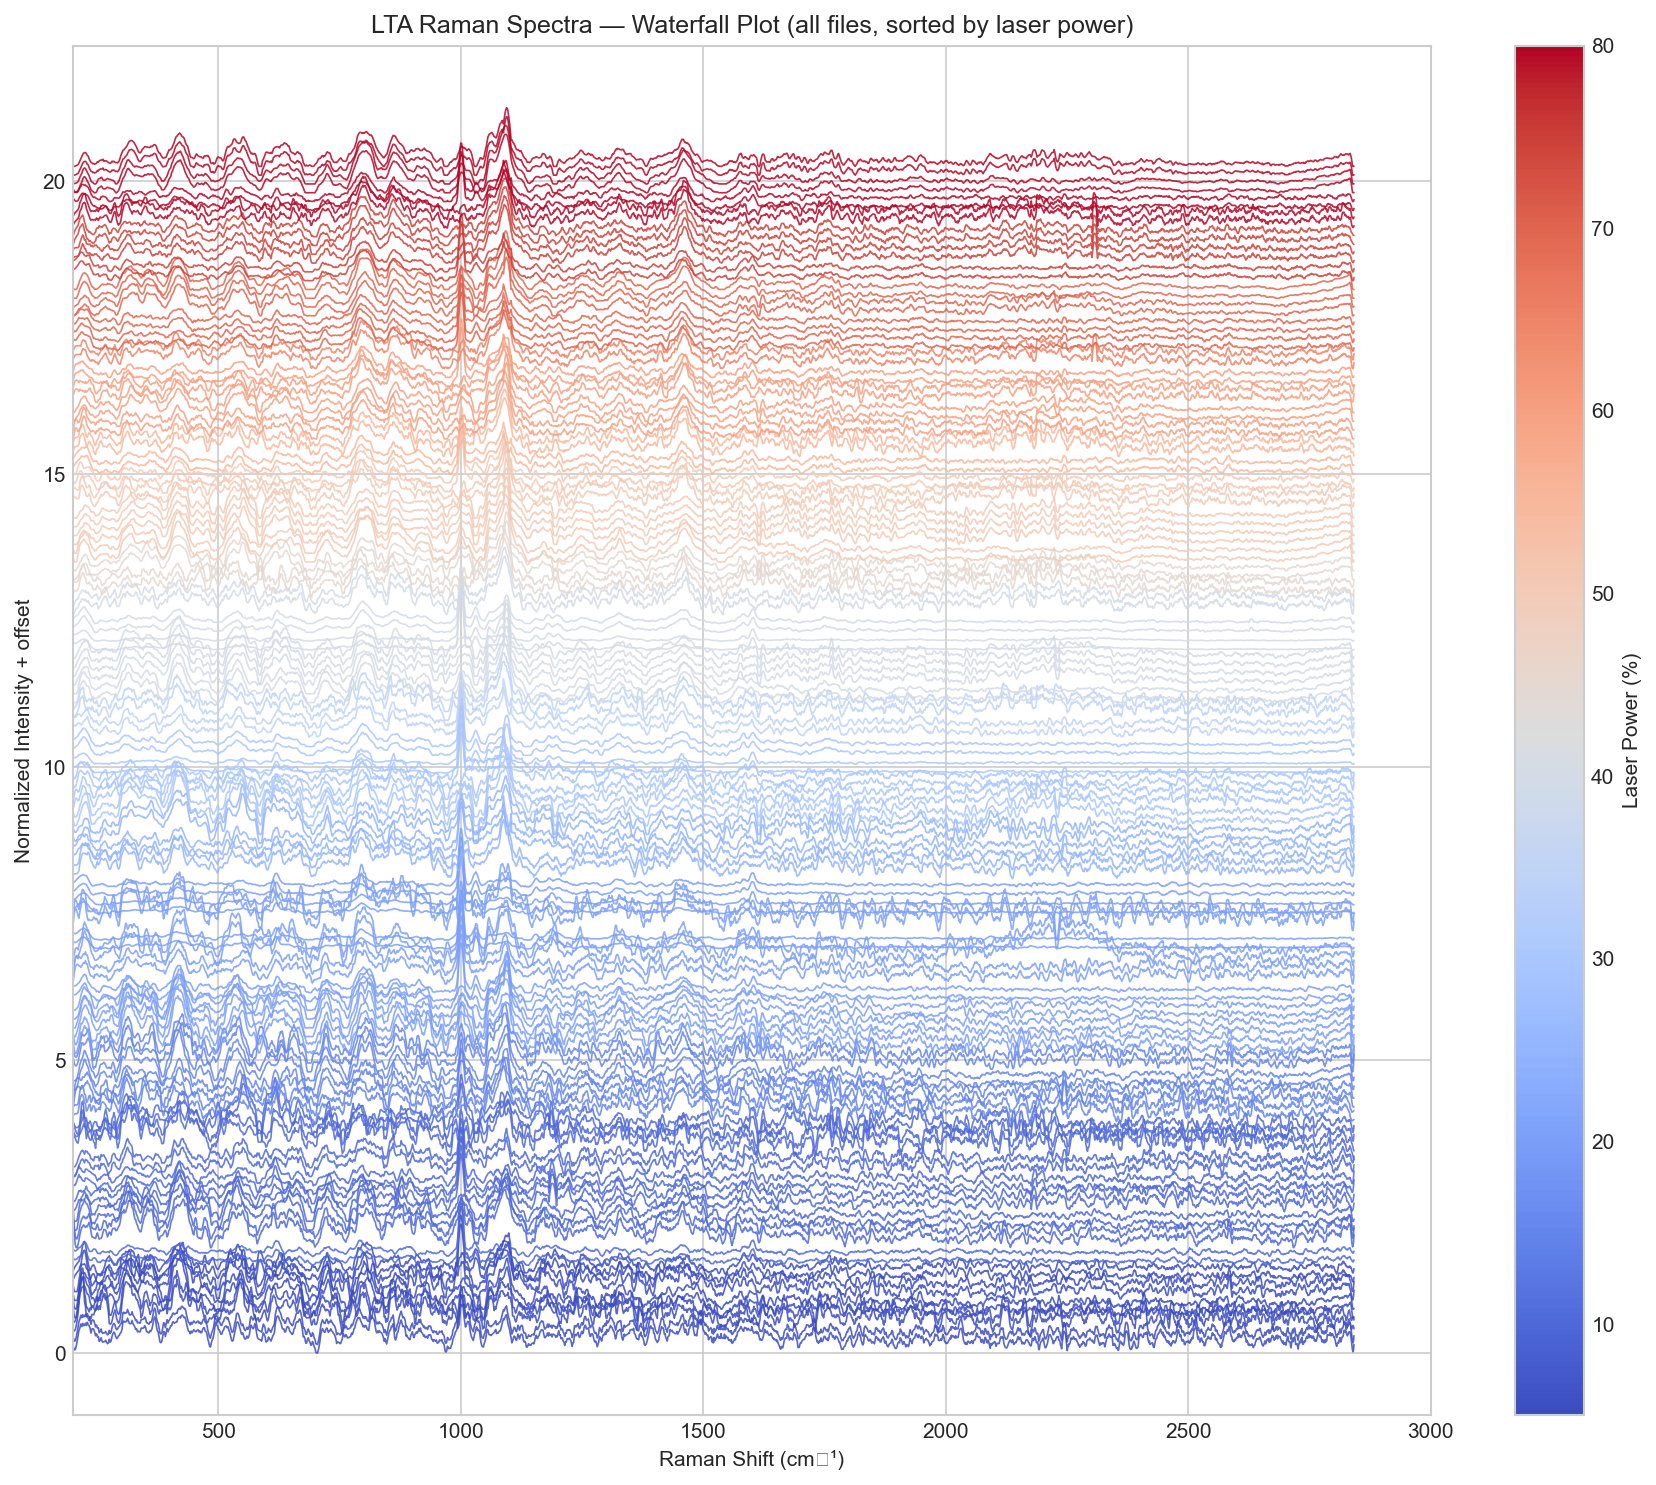

CELL 10 — Figure 4: All Spectra Waterfall Plot
What was done:
  Plotted all spectra sorted by laser power.
  Blue → low power, Red → high power (coolwarm colormap).
  Vertical offset for clarity.

Total spectra plotted : 136
Power range           : 5% – 80%

Saved: fig04_all_spectra_waterfall.png
Status: ✅ Figure 4 saved.


In [9]:
sorted_df = ranked_df.sort_values('power')
powers    = sorted_df['power'].values
cmap      = cm.coolwarm
norm_p    = plt.Normalize(powers.min(), powers.max())

fig, ax = plt.subplots(figsize=(12, 10))
offset = 0
n_plotted = 0
for _, row in sorted_df.iterrows():
    x, y = preprocess_spectrum(row['filepath'])
    if x is None: continue
    color = cmap(norm_p(row['power']))
    ax.plot(x, y + offset, color=color, lw=0.8, alpha=0.85)
    offset += 0.15
    n_plotted += 1

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_p)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Laser Power (%)')
ax.set_xlabel('Raman Shift (cm⁻¹)')
ax.set_ylabel('Normalized Intensity + offset')
ax.set_title('LTA Raman Spectra — Waterfall Plot (all files, sorted by laser power)')
ax.set_xlim(SHIFT_MIN, SHIFT_MAX)
plt.tight_layout()
fig_path = os.path.join(FIG_FOLDER, "fig04_all_spectra_waterfall.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("CELL 10 — Figure 4: All Spectra Waterfall Plot")
print("=" * 60)
print("What was done:")
print("  Plotted all spectra sorted by laser power.")
print("  Blue → low power, Red → high power (coolwarm colormap).")
print("  Vertical offset for clarity.")
print()
print(f"Total spectra plotted : {n_plotted}")
print(f"Power range           : {powers.min()}% – {powers.max()}%")
print()
print("Saved: fig04_all_spectra_waterfall.png")
print("Status: ✅ Figure 4 saved.")


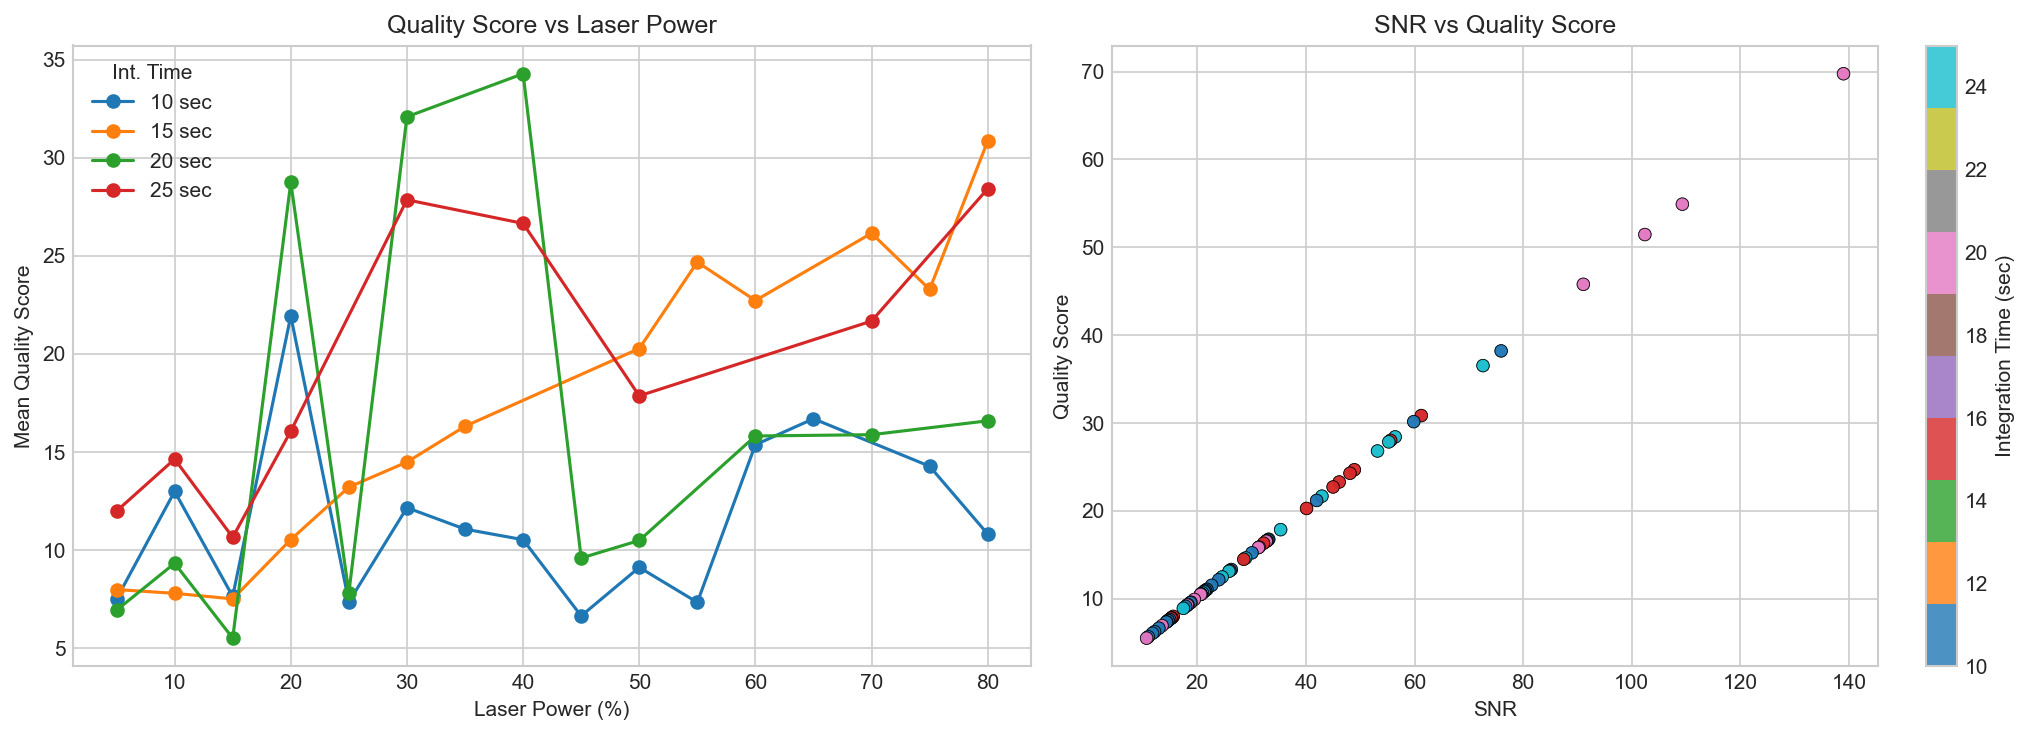

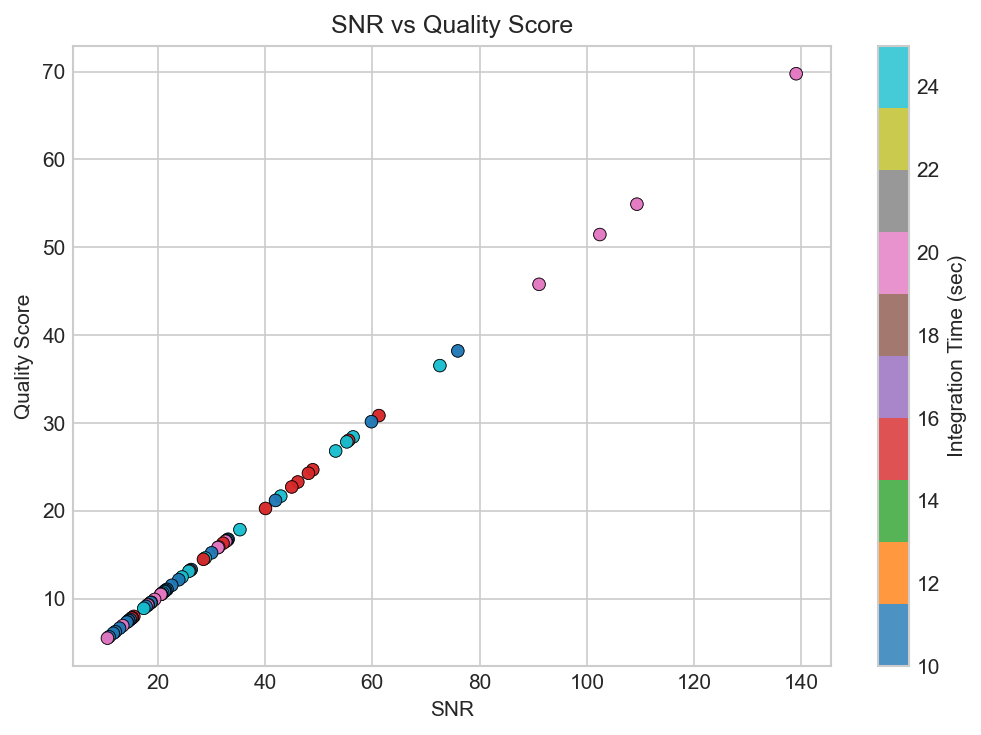

CELL 11 — Figures 5 & 6: Score Trends
What was done:
  Fig 5: Mean quality score vs laser power, one line per integration time.
  Fig 6: SNR vs quality score scatter, colour-coded by integration time.

Highest mean score power   : 40%
Highest mean score int time: 20 sec

Saved: fig05_score_vs_power.png
Saved: fig06_SNR_vs_score.png
Status: ✅ Figures 5 & 6 saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fig 5 — Score vs Laser Power
for s in sorted(ranked_df['sec'].unique()):
    sub = ranked_df[ranked_df['sec']==s].groupby('power')['score'].mean().reset_index()
    axes[0].plot(sub['power'], sub['score'], marker='o', label=f'{s} sec')
axes[0].set_xlabel('Laser Power (%)')
axes[0].set_ylabel('Mean Quality Score')
axes[0].set_title('Quality Score vs Laser Power')
axes[0].legend(title='Int. Time')

# Fig 6 — SNR vs Score
sc6 = axes[1].scatter(ranked_df['snr'], ranked_df['score'],
                      c=ranked_df['sec'], cmap='tab10', alpha=0.8, edgecolors='k', lw=0.4)
plt.colorbar(sc6, ax=axes[1], label='Integration Time (sec)')
axes[1].set_xlabel('SNR')
axes[1].set_ylabel('Quality Score')
axes[1].set_title('SNR vs Quality Score')

plt.tight_layout()
p5 = os.path.join(FIG_FOLDER, "fig05_score_vs_power.png")
p6 = os.path.join(FIG_FOLDER, "fig06_SNR_vs_score.png")
fig.savefig(p5, dpi=150, bbox_inches='tight')

fig2, ax2 = plt.subplots(figsize=(7, 5))
sc = ax2.scatter(ranked_df['snr'], ranked_df['score'],
                 c=ranked_df['sec'], cmap='tab10', alpha=0.8, edgecolors='k', lw=0.4)
plt.colorbar(sc, ax=ax2, label='Integration Time (sec)')
ax2.set_xlabel('SNR')
ax2.set_ylabel('Quality Score')
ax2.set_title('SNR vs Quality Score')
plt.tight_layout()
fig2.savefig(p6, dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("CELL 11 — Figures 5 & 6: Score Trends")
print("=" * 60)
print("What was done:")
print("  Fig 5: Mean quality score vs laser power, one line per integration time.")
print("  Fig 6: SNR vs quality score scatter, colour-coded by integration time.")
print()
best_power_group = ranked_df.groupby('power')['score'].mean().idxmax()
best_sec_group   = ranked_df.groupby('sec')['score'].mean().idxmax()
print(f"Highest mean score power   : {best_power_group}%")
print(f"Highest mean score int time: {best_sec_group} sec")
print()
print("Saved: fig05_score_vs_power.png")
print("Saved: fig06_SNR_vs_score.png")
print("Status: ✅ Figures 5 & 6 saved.")


In [11]:
sim_available = os.path.exists(SIM_FILE)

if sim_available:
    sim_raw = pd.read_excel(SIM_FILE, header=0)
    sim_raw = sim_raw.iloc[:, :2].copy()
    sim_raw.columns = ['freq', 'activity']
    sim_raw = sim_raw.dropna()
    sim_raw['freq']     = pd.to_numeric(sim_raw['freq'],     errors='coerce')
    sim_raw['activity'] = pd.to_numeric(sim_raw['activity'], errors='coerce')
    sim_raw = sim_raw.dropna()
    sim_raw = sim_raw[sim_raw['freq'] > 0]
    n_raw = len(sim_raw)
    sim_raw['freq_scaled'] = sim_raw['freq'] * DFT_SCALE
    sim_filt = sim_raw[(sim_raw['freq_scaled'] >= SHIFT_MIN) &
                       (sim_raw['freq_scaled'] <= SHIFT_MAX)].copy()
    sim_filt['activity'] = sim_filt['activity'] / sim_filt['activity'].max()

    grid = np.arange(SHIFT_MIN, SHIFT_MAX, 0.5)
    sim_broad = gaussian_broaden(sim_filt['freq_scaled'].values,
                                 sim_filt['activity'].values, grid)

    print("=" * 60)
    print("CELL 12 — DFT Simulation Data Loaded")
    print("=" * 60)
    print("What was done:")
    print("  Loaded simdata.xlsx.")
    print("  Removed negative frequencies.")
    print(f"  Applied DFT scaling factor: {DFT_SCALE}")
    print("  Applied Gaussian broadening.")
    print("  Normalized to 0–1.")
    print()
    print(f"Simulated peaks (raw)           : {n_raw}")
    print(f"Simulated peaks in 200–3000 cm⁻¹: {len(sim_filt)}")
    print(f"Broadening FWHM                  : {BROAD_FWHM} cm⁻¹")
    print()
    print("Top 10 most intense simulated peaks (scaled):")
    top_sim = sim_filt.nlargest(10, 'activity')[['freq_scaled','activity']]
    top_sim.columns = ['Scaled Freq (cm⁻¹)', 'Norm. Activity']
    print(top_sim.to_string(index=False))
    print()
    print("Status: ✅ DFT simulation loaded.")
else:
    sim_filt  = None
    sim_broad = None
    grid      = None
    print("⚠️  simdata.xlsx not found.")
    print("   DFT comparison cells (12–22) will be skipped.")
    print("   Add simdata.xlsx to the working folder to enable comparison.")


CELL 12 — DFT Simulation Data Loaded
What was done:
  Loaded simdata.xlsx.
  Removed negative frequencies.
  Applied DFT scaling factor: 0.98
  Applied Gaussian broadening.
  Normalized to 0–1.

Simulated peaks (raw)           : 444
Simulated peaks in 200–3000 cm⁻¹: 317
Broadening FWHM                  : 10 cm⁻¹

Top 10 most intense simulated peaks (scaled):
 Scaled Freq (cm⁻¹)  Norm. Activity
            2667.56        1.000000
             242.06        0.656141
            2976.26        0.596460
            2993.90        0.573755
             780.08        0.503946
            1274.00        0.492380
            1265.18        0.483991
             471.38        0.434331
             347.90        0.430544
            2949.80        0.429995

Status: ✅ DFT simulation loaded.


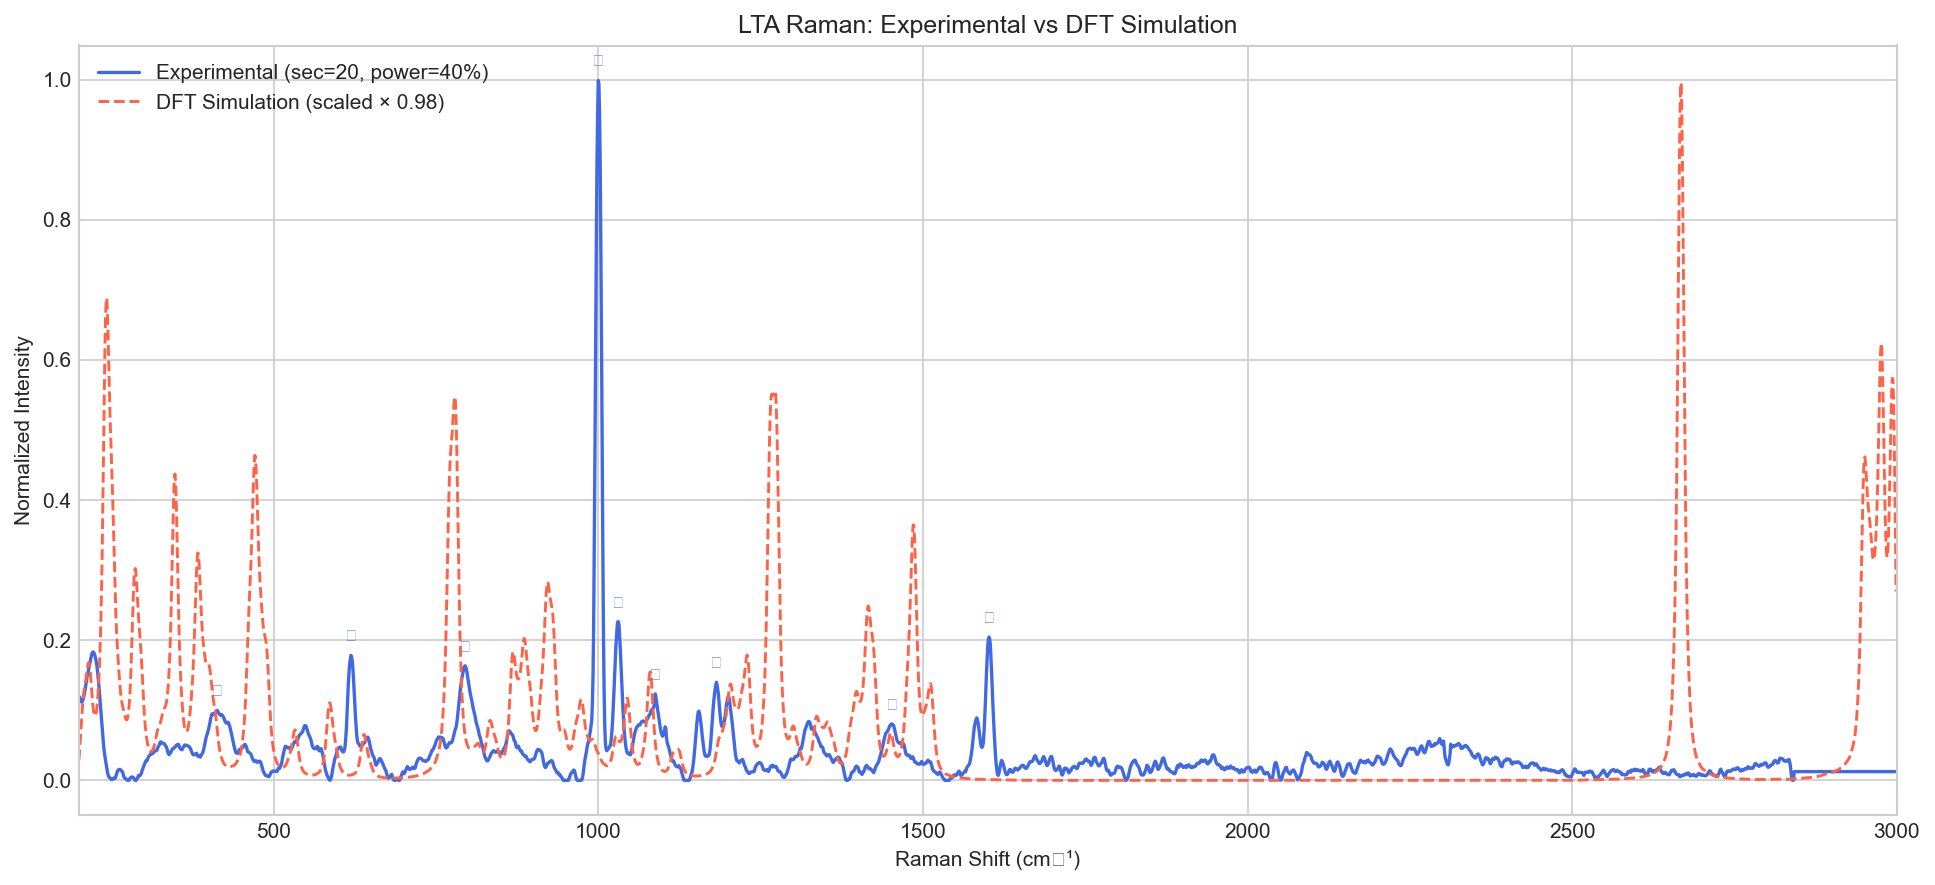

CELL 13 — Figure 3: Experimental vs DFT Overlay
What was done:
  Interpolated experimental and DFT spectra to common grid.
  Plotted overlay: blue = experiment, red dashed = DFT.
  Marked experimental peak positions with ▾ markers.

Experimental file : sec-20_power-40_i-2_2.xlsx
DFT scale factor  : 0.98

Saved: fig03_experimental_vs_DFT_overlay.png
Status: ✅ Figure 3 saved.


In [12]:
if sim_available:
    common_grid = np.arange(SHIFT_MIN, SHIFT_MAX, 1.0)
    exp_interp  = np.interp(common_grid, best_x, best_y)
    sim_interp  = np.interp(common_grid, grid, sim_broad)

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(common_grid, exp_interp, color='royalblue', lw=1.6,
            label=f"Experimental (sec={best['sec']}, power={best['power']}%)")
    ax.plot(common_grid, sim_interp, color='tomato', lw=1.4, ls='--',
            label=f"DFT Simulation (scaled × {DFT_SCALE})")

    exp_peaks, _ = find_peaks(exp_interp, distance=15, prominence=0.08)
    for pk in exp_peaks:
        if 300 < common_grid[pk] < 1800:
            ax.annotate('▾', xy=(common_grid[pk], exp_interp[pk]+0.02),
                        ha='center', fontsize=8, color='royalblue')

    ax.set_xlabel('Raman Shift (cm⁻¹)')
    ax.set_ylabel('Normalized Intensity')
    ax.set_title('LTA Raman: Experimental vs DFT Simulation')
    ax.legend()
    ax.set_xlim(SHIFT_MIN, SHIFT_MAX)
    plt.tight_layout()
    fig_path = os.path.join(FIG_FOLDER, "fig03_experimental_vs_DFT_overlay.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()

    print("=" * 60)
    print("CELL 13 — Figure 3: Experimental vs DFT Overlay")
    print("=" * 60)
    print("What was done:")
    print("  Interpolated experimental and DFT spectra to common grid.")
    print("  Plotted overlay: blue = experiment, red dashed = DFT.")
    print("  Marked experimental peak positions with ▾ markers.")
    print()
    print(f"Experimental file : {best['filename']}")
    print(f"DFT scale factor  : {DFT_SCALE}")
    print()
    print("Saved: fig03_experimental_vs_DFT_overlay.png")
    print("Status: ✅ Figure 3 saved.")
else:
    print("Skipped — simdata.xlsx not found.")


In [13]:
if sim_available:
    exp_pks = peak_df['raman_shift'].values
    sim_pks = sim_filt['freq_scaled'].values

    match_rows = []
    for ep in exp_pks:
        diffs = np.abs(sim_pks - ep)
        nearest_idx = np.argmin(diffs)
        diff = sim_pks[nearest_idx] - ep
        matched = abs(diff) <= MATCH_TOLERANCE
        match_rows.append({
            'exp_peak_cm1'  : round(ep, 1),
            'sim_peak_cm1'  : round(sim_pks[nearest_idx], 1),
            'difference_cm1': round(diff, 1),
            'matched'       : matched,
        })

    match_df = pd.DataFrame(match_rows)
    match_df.to_csv(os.path.join(DATA_OUT_FOLDER, "peak_matching_table.csv"), index=False)

    n_matched   = match_df['matched'].sum()
    n_unmatched = (~match_df['matched']).sum()

    print("=" * 60)
    print("CELL 14 — Peak Matching: Experimental vs Simulated")
    print("=" * 60)
    print("What was done:")
    print("  For each experimental peak, found nearest simulated peak.")
    print(f"  Match criterion: |difference| ≤ {MATCH_TOLERANCE} cm⁻¹")
    print()
    print(f"Experimental peaks : {len(exp_pks)}")
    print(f"Matched peaks      : {n_matched}")
    print(f"Unmatched peaks    : {n_unmatched}")
    print()
    print("Peak Matching Table:")
    print(match_df.to_string(index=False))
    print()
    print("Saved: peak_matching_table.csv")
    print("Status: ✅ Peak matching complete.")
else:
    match_df = pd.DataFrame()
    print("Skipped — simdata.xlsx not found.")


CELL 14 — Peak Matching: Experimental vs Simulated
What was done:
  For each experimental peak, found nearest simulated peak.
  Match criterion: |difference| ≤ 15 cm⁻¹

Experimental peaks : 7
Matched peaks      : 7
Unmatched peaks    : 0

Peak Matching Table:
 exp_peak_cm1  sim_peak_cm1  difference_cm1  matched
        412.5         409.6            -2.9     True
        619.0         621.3             2.4     True
        794.8         797.7             2.9     True
        999.8        1000.6             0.8     True
       1030.4        1027.0            -3.3     True
       1181.8        1185.8             4.0     True
       1601.3        1600.3            -1.0     True

Saved: peak_matching_table.csv
Status: ✅ Peak matching complete.


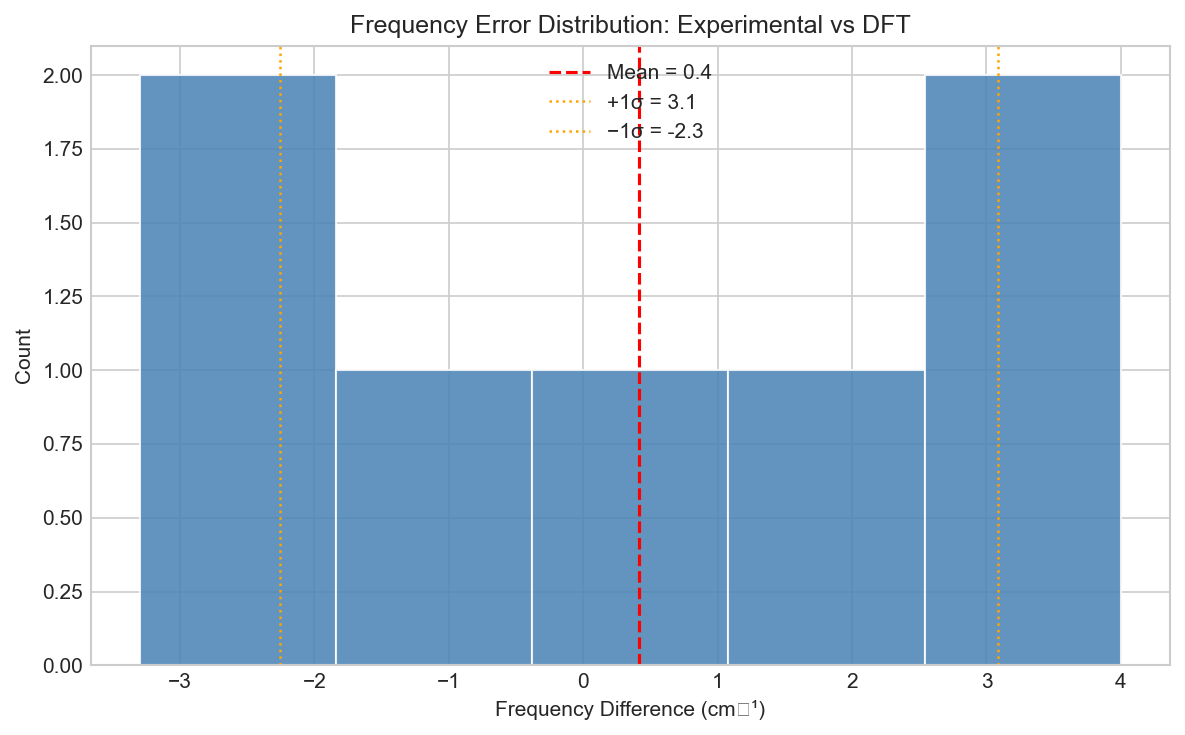

CELL 15 — Figure 7: Frequency Error Histogram
What was done:
  Computed error statistics for matched peaks.
  Plotted histogram with mean and ±1σ lines.

Mean error         : 0.41 cm⁻¹
Median error       : 0.80 cm⁻¹
Std deviation      : 2.67 cm⁻¹
RMSE               : 2.70 cm⁻¹
Max absolute error : 4.00 cm⁻¹

Saved: fig07_frequency_error_histogram.png
Status: ✅ Figure 7 saved.


In [14]:
if sim_available and len(match_df) > 0:
    matched_only = match_df[match_df['matched']].copy()
    diffs = matched_only['difference_cm1'].values

    mean_err   = np.mean(diffs)
    median_err = np.median(diffs)
    std_err    = np.std(diffs)
    rmse       = np.sqrt(np.mean(diffs**2))
    max_err    = np.max(np.abs(diffs))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(diffs, bins=max(5, len(diffs)//2), color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(mean_err,        color='red',    ls='--', lw=1.5, label=f'Mean = {mean_err:.1f}')
    ax.axvline(mean_err+std_err, color='orange', ls=':',  lw=1.2, label=f'+1σ = {mean_err+std_err:.1f}')
    ax.axvline(mean_err-std_err, color='orange', ls=':',  lw=1.2, label=f'−1σ = {mean_err-std_err:.1f}')
    ax.set_xlabel('Frequency Difference (cm⁻¹)')
    ax.set_ylabel('Count')
    ax.set_title('Frequency Error Distribution: Experimental vs DFT')
    ax.legend()
    plt.tight_layout()
    fig_path = os.path.join(FIG_FOLDER, "fig07_frequency_error_histogram.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()

    print("=" * 60)
    print("CELL 15 — Figure 7: Frequency Error Histogram")
    print("=" * 60)
    print("What was done:")
    print("  Computed error statistics for matched peaks.")
    print("  Plotted histogram with mean and ±1σ lines.")
    print()
    print(f"Mean error         : {mean_err:.2f} cm⁻¹")
    print(f"Median error       : {median_err:.2f} cm⁻¹")
    print(f"Std deviation      : {std_err:.2f} cm⁻¹")
    print(f"RMSE               : {rmse:.2f} cm⁻¹")
    print(f"Max absolute error : {max_err:.2f} cm⁻¹")
    print()
    print("Saved: fig07_frequency_error_histogram.png")
    print("Status: ✅ Figure 7 saved.")
else:
    mean_err = median_err = std_err = rmse = max_err = float('nan')
    print("Skipped — simdata.xlsx not found or no matched peaks.")


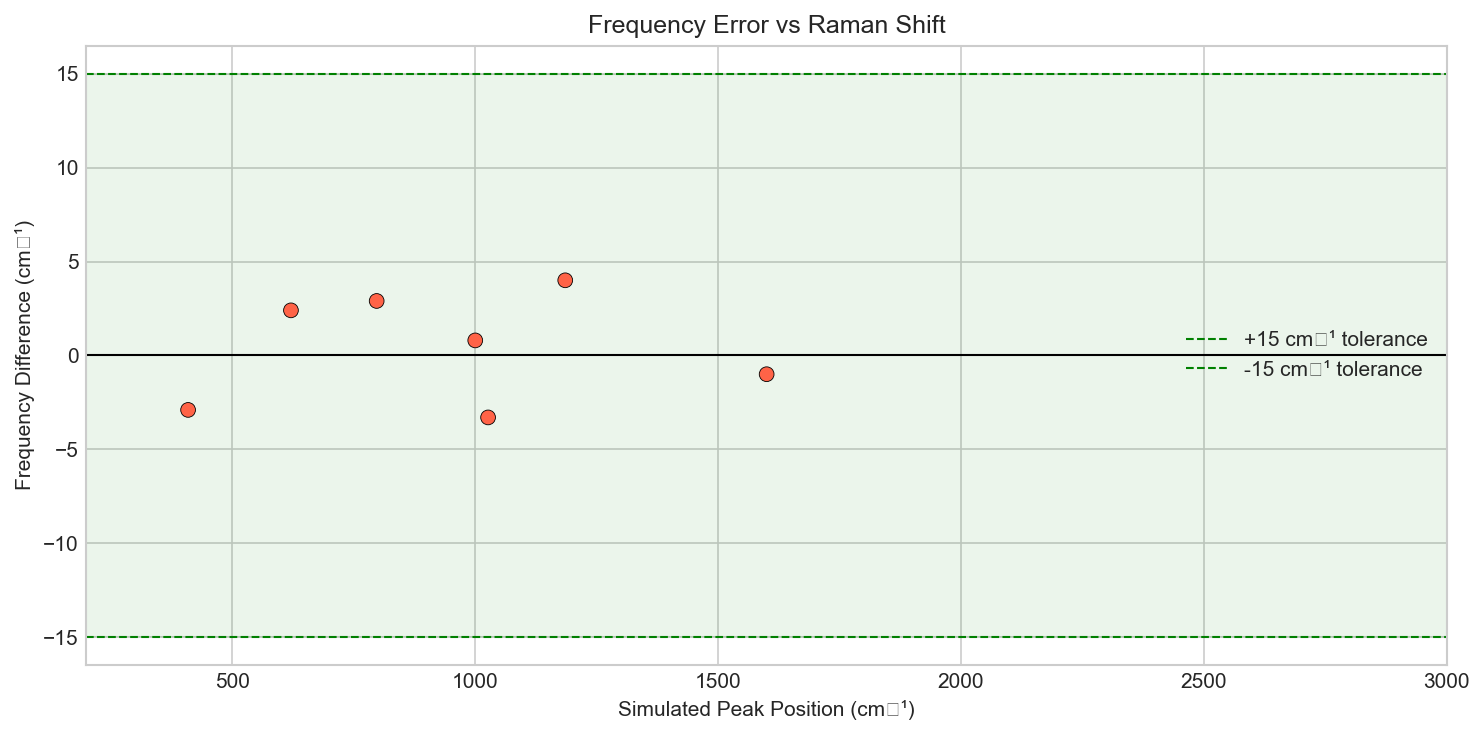

CELL 16 — Figure 8: Error vs Raman Shift
What was done:
  Plotted frequency difference vs simulated peak position.
  Green band shows ±15 cm⁻¹ tolerance window.
  Red = matched, grey = unmatched.

Saved: fig08_error_vs_raman_shift.png
Status: ✅ Figure 8 saved.


In [15]:
if sim_available and len(match_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    colors_pt = ['tomato' if m else 'gray' for m in match_df['matched']]
    ax.scatter(match_df['sim_peak_cm1'], match_df['difference_cm1'],
               c=colors_pt, edgecolors='k', lw=0.4, zorder=3, s=50)
    ax.axhline(0,  color='black', lw=1)
    ax.axhline( MATCH_TOLERANCE, color='green', ls='--', lw=1, label=f'+{MATCH_TOLERANCE} cm⁻¹ tolerance')
    ax.axhline(-MATCH_TOLERANCE, color='green', ls='--', lw=1, label=f'-{MATCH_TOLERANCE} cm⁻¹ tolerance')
    ax.fill_between([SHIFT_MIN, SHIFT_MAX], -MATCH_TOLERANCE, MATCH_TOLERANCE,
                    alpha=0.08, color='green')
    ax.set_xlabel('Simulated Peak Position (cm⁻¹)')
    ax.set_ylabel('Frequency Difference (cm⁻¹)')
    ax.set_title('Frequency Error vs Raman Shift')
    ax.legend()
    ax.set_xlim(SHIFT_MIN, SHIFT_MAX)
    plt.tight_layout()
    fig_path = os.path.join(FIG_FOLDER, "fig08_error_vs_raman_shift.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()

    print("=" * 60)
    print("CELL 16 — Figure 8: Error vs Raman Shift")
    print("=" * 60)
    print("What was done:")
    print("  Plotted frequency difference vs simulated peak position.")
    print("  Green band shows ±15 cm⁻¹ tolerance window.")
    print("  Red = matched, grey = unmatched.")
    print()
    print("Saved: fig08_error_vs_raman_shift.png")
    print("Status: ✅ Figure 8 saved.")
else:
    print("Skipped — simdata.xlsx not found.")


In [16]:
if sim_available:
    common_grid2 = np.arange(SHIFT_MIN, SHIFT_MAX, 1.0)
    exp_i = np.interp(common_grid2, best_x, best_y)
    sim_i = np.interp(common_grid2, grid, sim_broad)

    cosine  = np.dot(exp_i, sim_i) / (np.linalg.norm(exp_i) * np.linalg.norm(sim_i))
    pearson, _ = pearsonr(exp_i, sim_i)
    residual = exp_i - sim_i

    print("=" * 60)
    print("CELL 17 — Spectral Similarity Metrics")
    print("=" * 60)
    print("What was done:")
    print("  Interpolated both spectra to a 1 cm⁻¹ common grid.")
    print("  Computed cosine similarity and Pearson correlation.")
    print("  Computed residual spectrum.")
    print()
    print(f"Cosine Similarity  : {cosine:.4f}")
    print(f"Pearson Correlation: {pearson:.4f}")
    print()
    if cosine > 0.9:
        print("Interpretation: ✅ Excellent spectral match.")
    elif cosine > 0.7:
        print("Interpretation: ✅ Good spectral match.")
    else:
        print("Interpretation: ⚠️  Moderate match — check scaling factor.")
    print()
    print("Status: ✅ Similarity metrics computed.")
else:
    cosine = pearson = residual = float('nan')
    exp_i = sim_i = common_grid2 = None
    print("Skipped — simdata.xlsx not found.")


CELL 17 — Spectral Similarity Metrics
What was done:
  Interpolated both spectra to a 1 cm⁻¹ common grid.
  Computed cosine similarity and Pearson correlation.
  Computed residual spectrum.

Cosine Similarity  : 0.2397
Pearson Correlation: -0.0084

Interpretation: ⚠️  Moderate match — check scaling factor.

Status: ✅ Similarity metrics computed.


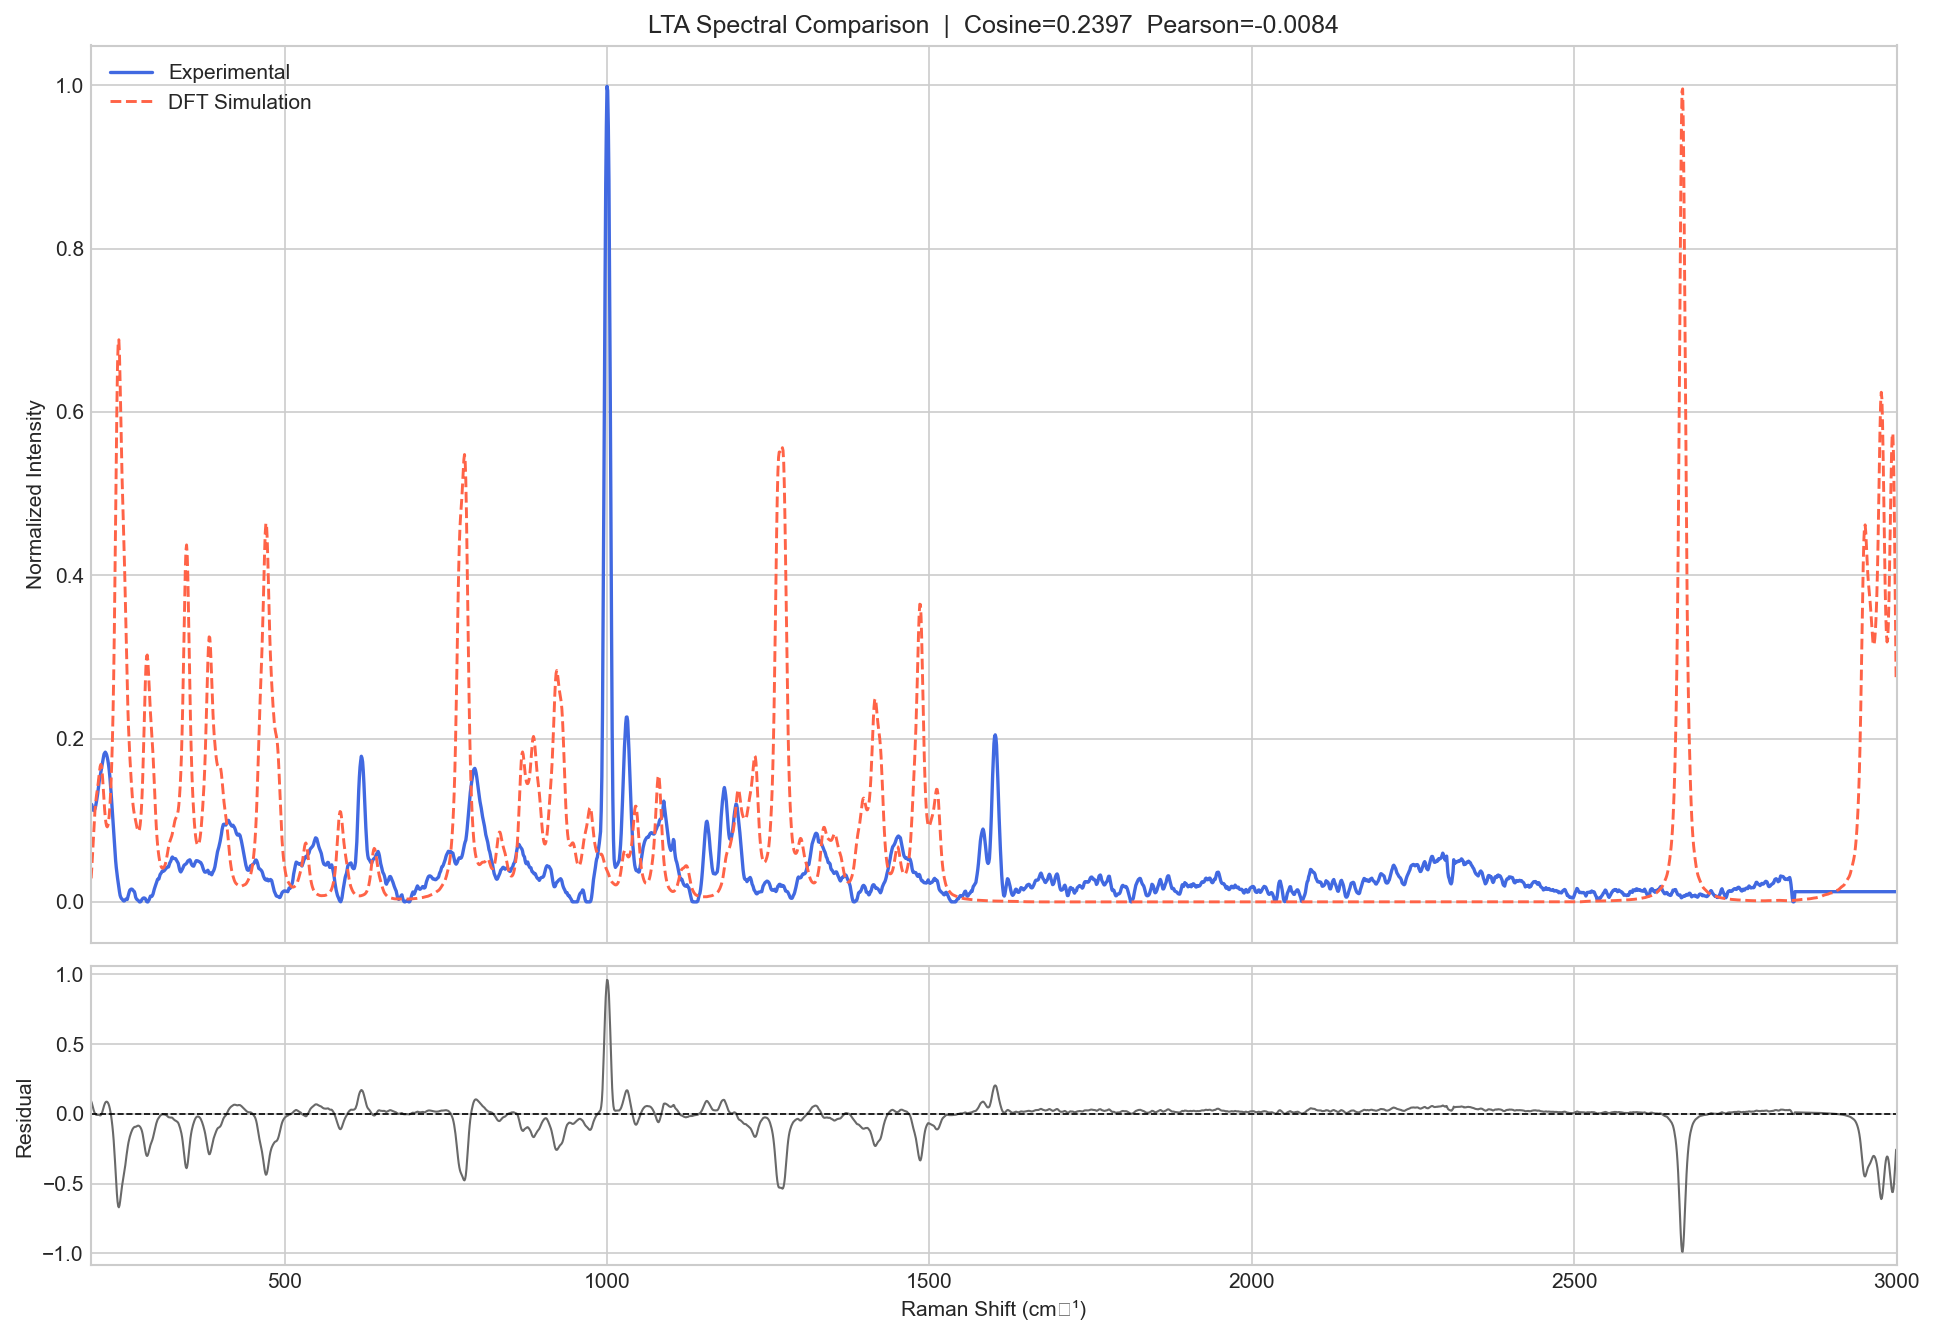

CELL 18 — Figure 9: Spectral Similarity Overlay + Residual
What was done:
  Top panel: experimental (blue) vs DFT (red dashed) overlay.
  Bottom panel: residual (experimental − simulation).

Cosine similarity  : 0.2397
Pearson correlation: -0.0084

Saved: fig09_spectral_similarity_overlay.png
Status: ✅ Figure 9 saved.


In [17]:
if sim_available:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9),
                                   gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    ax1.plot(common_grid2, exp_i, color='royalblue', lw=1.6, label='Experimental')
    ax1.plot(common_grid2, sim_i, color='tomato',    lw=1.4, ls='--', label='DFT Simulation')
    ax1.set_ylabel('Normalized Intensity')
    ax1.set_title(f'LTA Spectral Comparison  |  Cosine={cosine:.4f}  Pearson={pearson:.4f}')
    ax1.legend()

    ax2.plot(common_grid2, residual, color='dimgray', lw=1.0)
    ax2.axhline(0, color='black', lw=0.8, ls='--')
    ax2.set_ylabel('Residual')
    ax2.set_xlabel('Raman Shift (cm⁻¹)')
    ax2.set_xlim(SHIFT_MIN, SHIFT_MAX)
    plt.tight_layout()
    fig_path = os.path.join(FIG_FOLDER, "fig09_spectral_similarity_overlay.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()

    print("=" * 60)
    print("CELL 18 — Figure 9: Spectral Similarity Overlay + Residual")
    print("=" * 60)
    print("What was done:")
    print("  Top panel: experimental (blue) vs DFT (red dashed) overlay.")
    print("  Bottom panel: residual (experimental − simulation).")
    print()
    print(f"Cosine similarity  : {cosine:.4f}")
    print(f"Pearson correlation: {pearson:.4f}")
    print()
    print("Saved: fig09_spectral_similarity_overlay.png")
    print("Status: ✅ Figure 9 saved.")
else:
    print("Skipped — simdata.xlsx not found.")


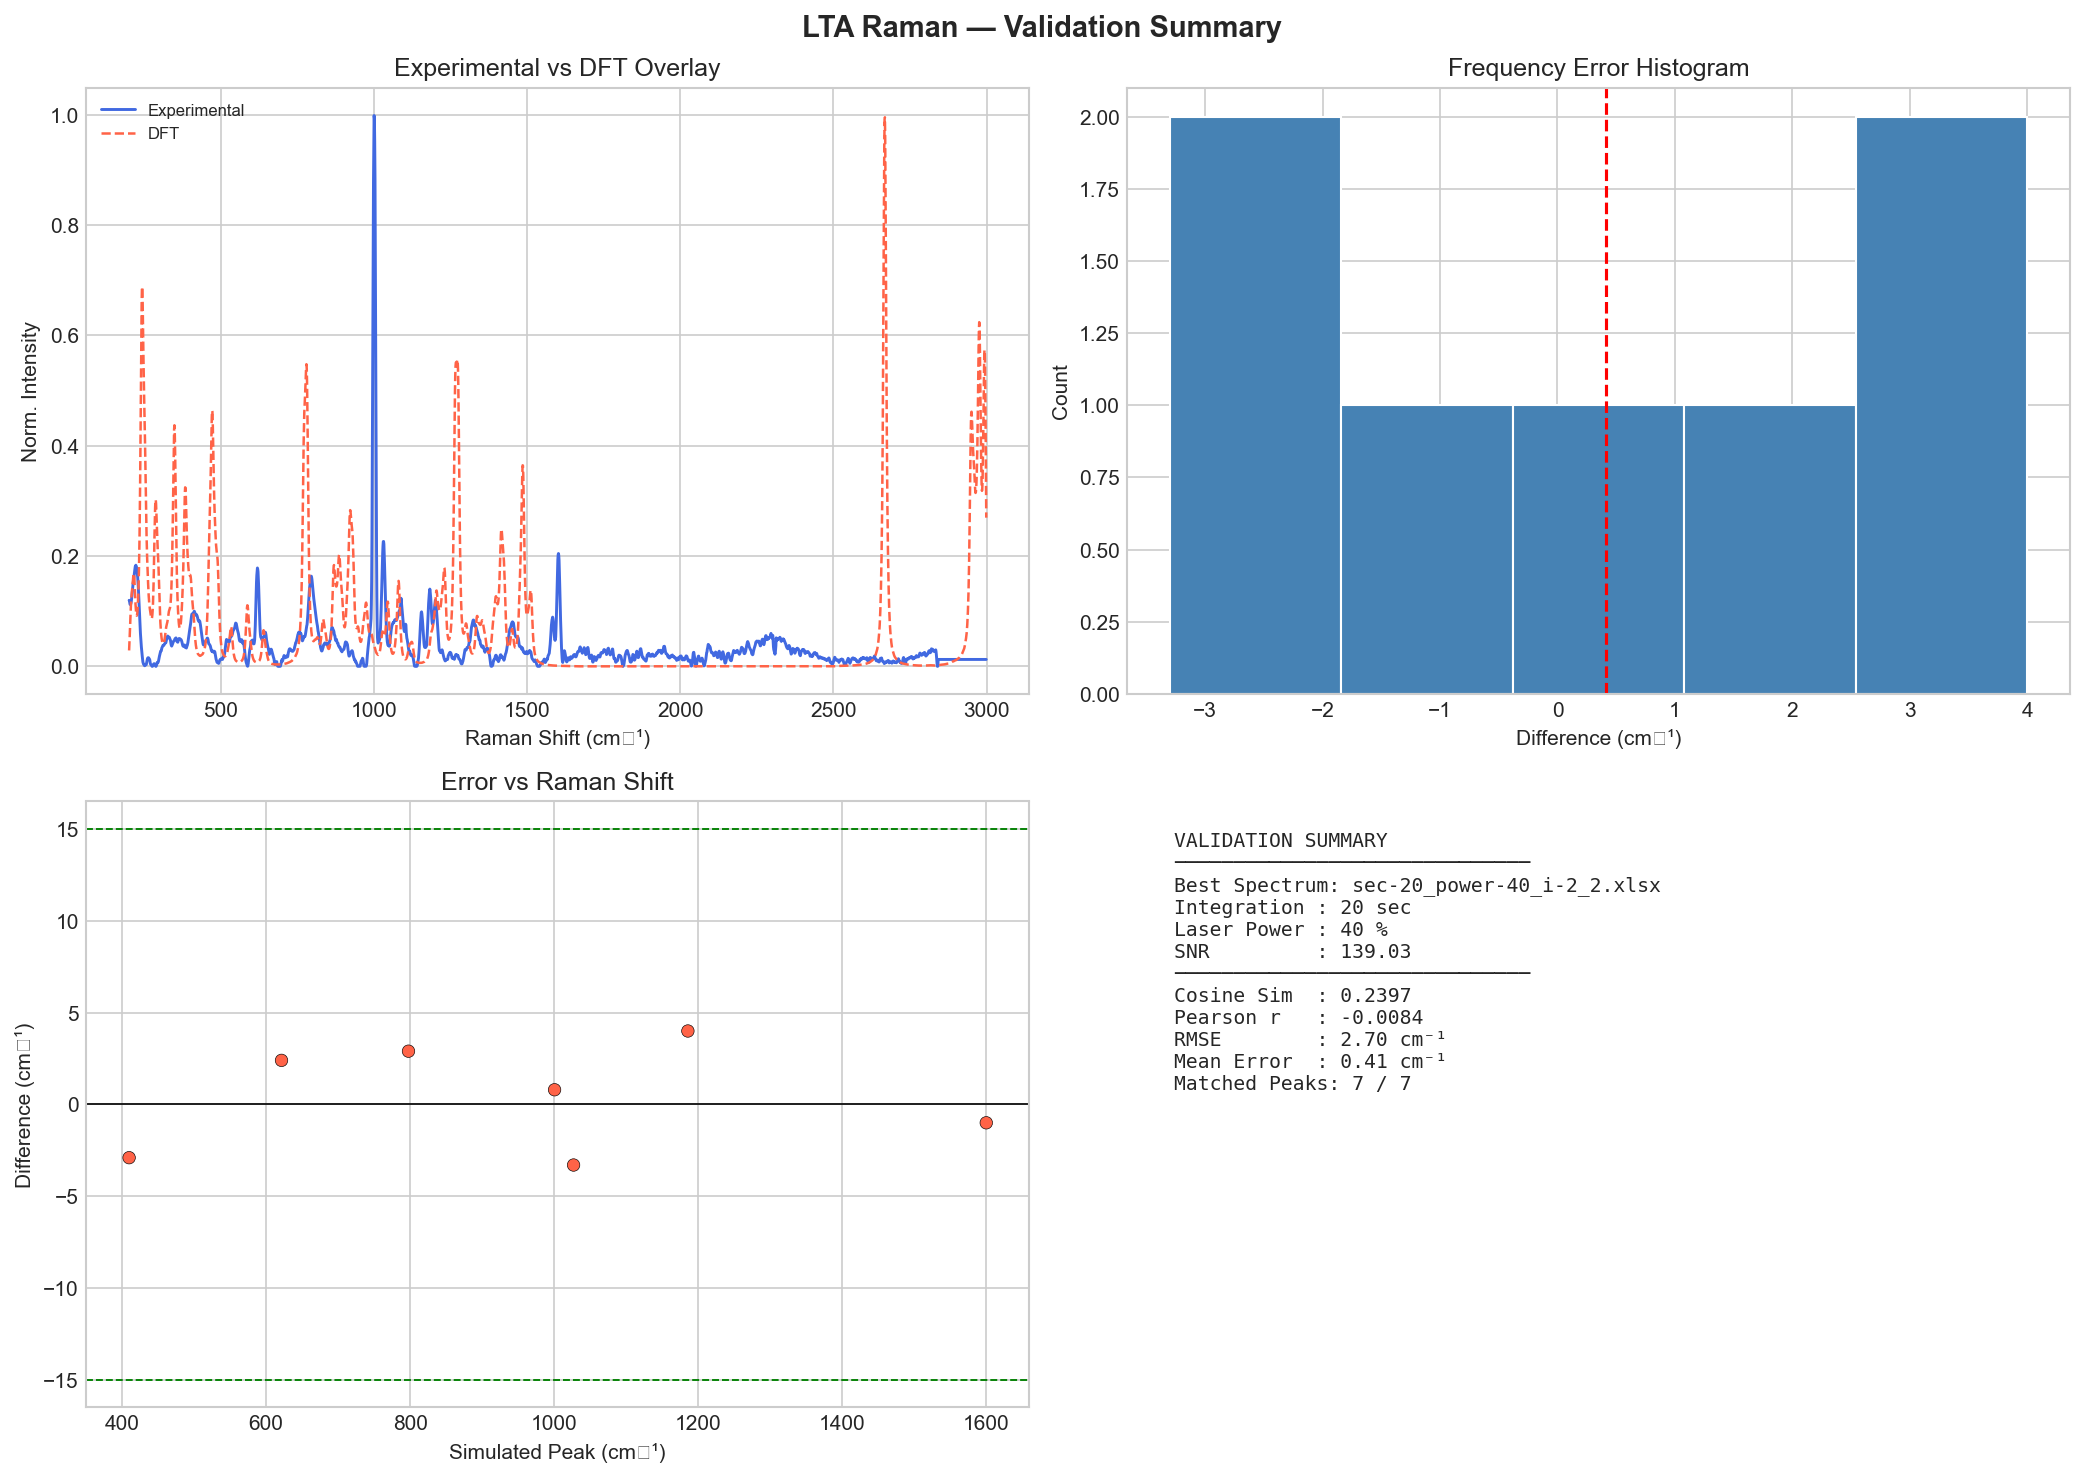

CELL 19 — Figure 10: 4-Panel Validation Summary
What was done:
  Panel 1: Overlay. Panel 2: Error histogram.
  Panel 3: Error vs shift. Panel 4: Key metrics text.

Saved: fig10_validation_summary_4panel.png
Status: ✅ Figure 10 saved.


In [18]:
if sim_available:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('LTA Raman — Validation Summary', fontsize=14, fontweight='bold')

    # Panel 1: overlay
    axes[0,0].plot(common_grid2, exp_i, 'royalblue', lw=1.4, label='Experimental')
    axes[0,0].plot(common_grid2, sim_i, 'tomato', lw=1.2, ls='--', label='DFT')
    axes[0,0].set_title('Experimental vs DFT Overlay')
    axes[0,0].set_xlabel('Raman Shift (cm⁻¹)')
    axes[0,0].set_ylabel('Norm. Intensity')
    axes[0,0].legend(fontsize=8)

    # Panel 2: histogram
    if len(match_df) > 0 and match_df['matched'].any():
        d = match_df[match_df['matched']]['difference_cm1'].values
        axes[0,1].hist(d, bins=max(5, len(d)//2), color='steelblue', edgecolor='white')
        axes[0,1].axvline(np.mean(d), color='red', ls='--', lw=1.5)
    axes[0,1].set_title('Frequency Error Histogram')
    axes[0,1].set_xlabel('Difference (cm⁻¹)')
    axes[0,1].set_ylabel('Count')

    # Panel 3: error vs shift
    if len(match_df) > 0:
        c_pt = ['tomato' if m else 'gray' for m in match_df['matched']]
        axes[1,0].scatter(match_df['sim_peak_cm1'], match_df['difference_cm1'],
                          c=c_pt, edgecolors='k', lw=0.3)
        axes[1,0].axhline(0, color='black', lw=0.8)
        axes[1,0].axhline( MATCH_TOLERANCE, color='green', ls='--', lw=0.9)
        axes[1,0].axhline(-MATCH_TOLERANCE, color='green', ls='--', lw=0.9)
    axes[1,0].set_title('Error vs Raman Shift')
    axes[1,0].set_xlabel('Simulated Peak (cm⁻¹)')
    axes[1,0].set_ylabel('Difference (cm⁻¹)')

    # Panel 4: text summary
    axes[1,1].axis('off')
    summary_text = (
        f"VALIDATION SUMMARY\n"
        f"{'─'*30}\n"
        f"Best Spectrum: {best['filename']}\n"
        f"Integration : {best['sec']} sec\n"
        f"Laser Power : {best['power']} %\n"
        f"SNR         : {best['snr']:.2f}\n"
        f"{'─'*30}\n"
        f"Cosine Sim  : {cosine:.4f}\n"
        f"Pearson r   : {pearson:.4f}\n"
        f"RMSE        : {rmse:.2f} cm⁻¹\n"
        f"Mean Error  : {mean_err:.2f} cm⁻¹\n"
        f"Matched Peaks: {match_df['matched'].sum() if len(match_df)>0 else 0} / {len(match_df)}"
    )
    axes[1,1].text(0.05, 0.95, summary_text, transform=axes[1,1].transAxes,
                   va='top', fontsize=9.5, fontfamily='monospace')

    plt.tight_layout()
    fig_path = os.path.join(FIG_FOLDER, "fig10_validation_summary_4panel.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()

    print("=" * 60)
    print("CELL 19 — Figure 10: 4-Panel Validation Summary")
    print("=" * 60)
    print("What was done:")
    print("  Panel 1: Overlay. Panel 2: Error histogram.")
    print("  Panel 3: Error vs shift. Panel 4: Key metrics text.")
    print()
    print("Saved: fig10_validation_summary_4panel.png")
    print("Status: ✅ Figure 10 saved.")
else:
    print("Skipped — simdata.xlsx not found.")


In [19]:
exp_shifts = best_x
exp_ints   = best_y

def find_nearest_exp(nominal, exp_shifts, exp_ints, window=20):
    mask = (exp_shifts > nominal - window) & (exp_shifts < nominal + window)
    if mask.sum() == 0: return np.nan, np.nan
    local_shifts = exp_shifts[mask]
    local_ints   = exp_ints[mask]
    best_idx = np.argmax(local_ints)
    return round(local_shifts[best_idx], 1), round(local_ints[best_idx], 4)

def find_nearest_sim(nominal, sim_df, window=20):
    if sim_df is None: return np.nan
    mask = (sim_df['freq_scaled'] > nominal - window) & (sim_df['freq_scaled'] < nominal + window)
    if mask.sum() == 0: return np.nan
    return round(sim_df[mask].nlargest(1, 'activity')['freq_scaled'].values[0], 1)

assign_rows = []
for nominal, assignment in LTA_PEAKS.items():
    ep, ei = find_nearest_exp(nominal, exp_shifts, exp_ints)
    sp = find_nearest_sim(nominal, sim_filt if sim_available else None)
    delta = round(ep - sp, 1) if (not np.isnan(ep) and not np.isnan(sp)) else np.nan
    assign_rows.append({
        'Nominal (cm⁻¹)'      : nominal,
        'Experimental (cm⁻¹)' : ep,
        'Simulated (cm⁻¹)'    : sp,
        'Δ (cm⁻¹)'            : delta,
        'Assignment'           : assignment,
    })

assign_df = pd.DataFrame(assign_rows)
assign_df.to_csv(os.path.join(DATA_OUT_FOLDER, "peak_assignment_table.csv"), index=False)

print("=" * 60)
print("CELL 20 — LTA Peak Assignment Table")
print("=" * 60)
print("What was done:")
print("  Mapped 16 nominal LTA literature peaks to experimental and simulated values.")
print("  Computed Δ = experimental − simulated for each.")
print()
print("LTA Raman Peak Assignments:")
print(assign_df.to_string(index=False))
print()
print("Saved: peak_assignment_table.csv")
print("Status: ✅ Peak assignment complete.")


CELL 20 — LTA Peak Assignment Table
What was done:
  Mapped 16 nominal LTA literature peaks to experimental and simulated values.
  Computed Δ = experimental − simulated for each.

LTA Raman Peak Assignments:
 Nominal (cm⁻¹)  Experimental (cm⁻¹)  Simulated (cm⁻¹)  Δ (cm⁻¹)                           Assignment
            720                724.9             736.0     -11.1     P-O-C vibration (phosphodiester)
            735                754.0             753.6       0.4 P-O-C vibration (phosphate backbone)
            870                861.9             885.9     -24.0        C-O-C ring stretch (glycerol)
            890                870.3             885.9     -15.6                   C-O-C ring stretch
           1000                999.8             991.8       8.0               C-C skeletal vibration
           1005                999.8             991.8       8.0                   C-C ring breathing
           1085               1087.8            1080.0       7.8             

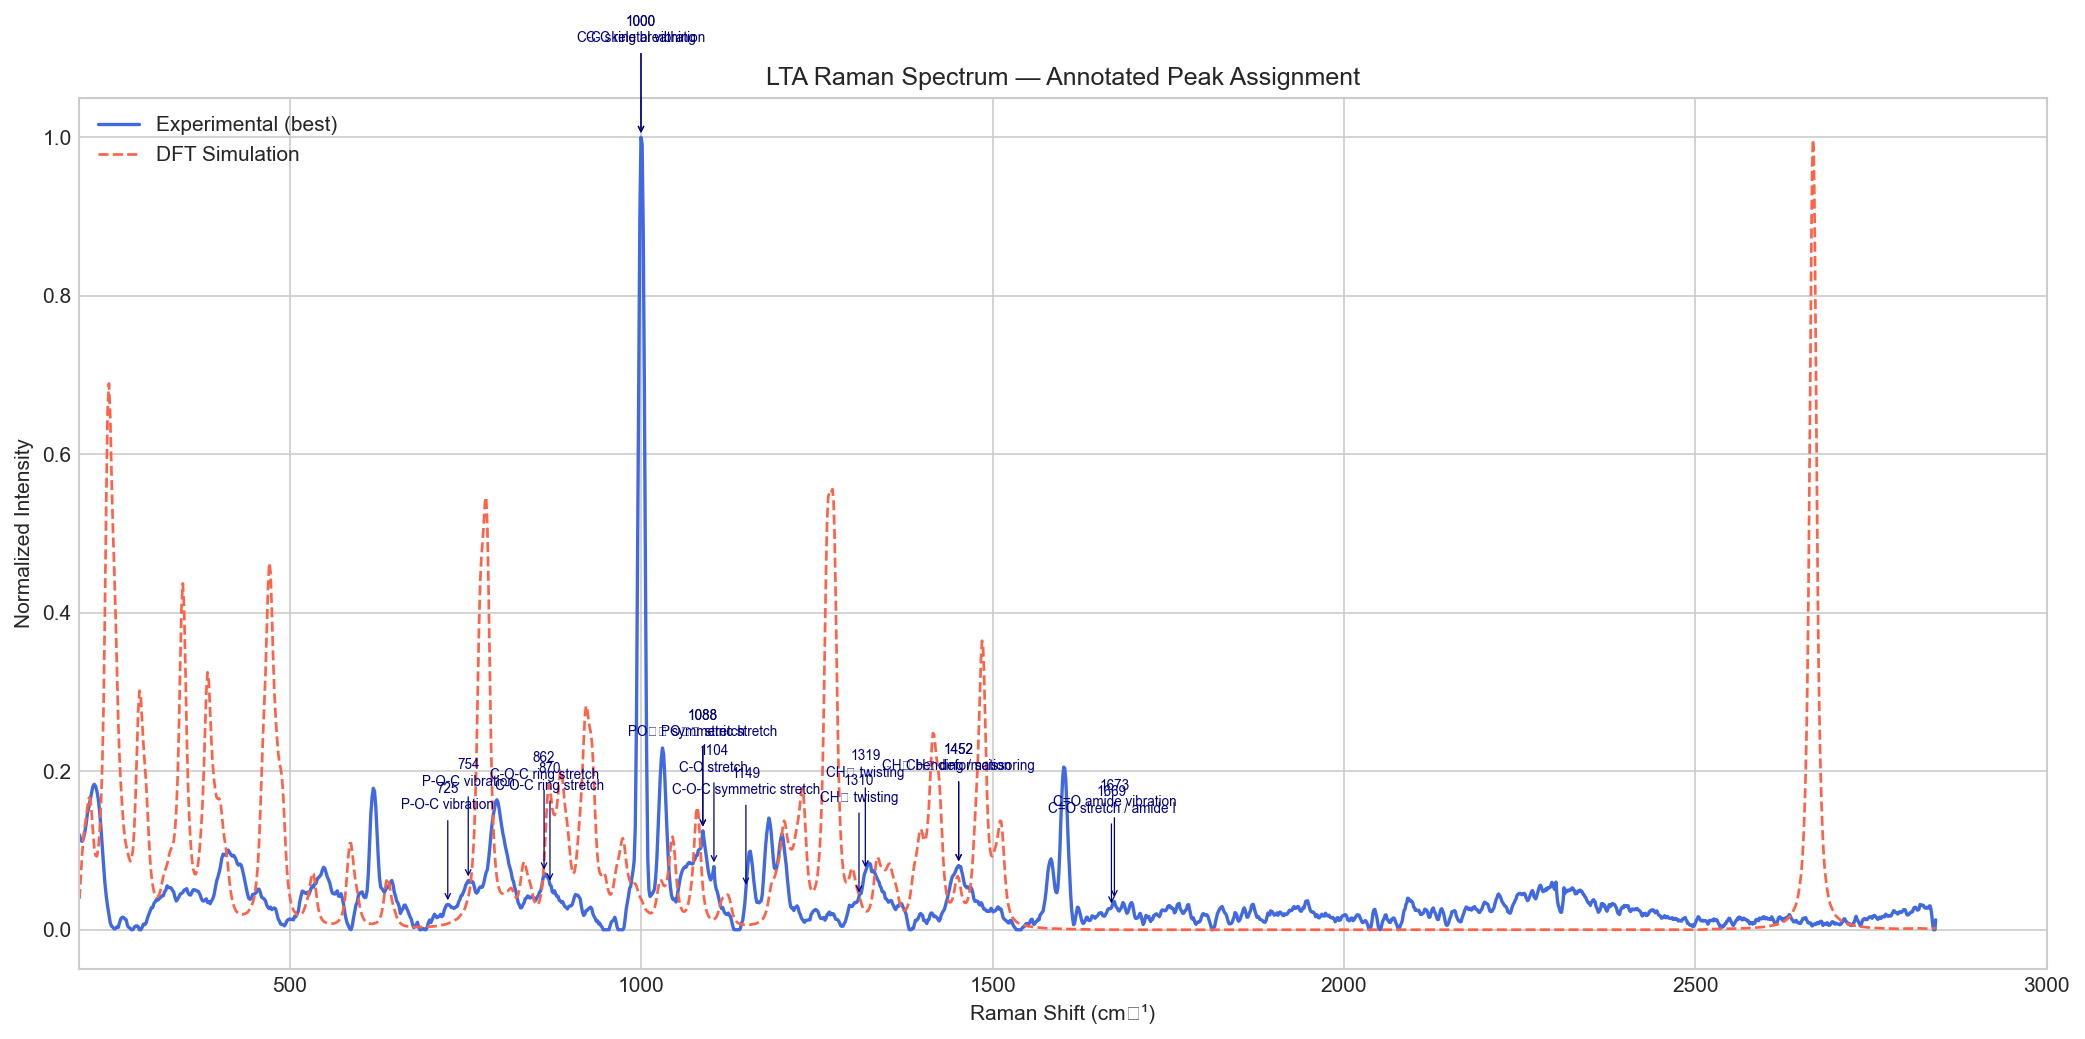

CELL 21 — Figure 11: Annotated Peak Assignment
What was done:
  Plotted best experimental and DFT spectra.
  Annotated all assigned LTA peaks with cm⁻¹ values
  and functional group labels.

Peaks annotated: 16

Saved: fig11_annotated_peak_assignment.png
Status: ✅ Figure 11 saved.


In [20]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(best_x, best_y, color='royalblue', lw=1.6, label='Experimental (best)')
if sim_available:
    sim_plot = np.interp(best_x, grid, sim_broad)
    ax.plot(best_x, sim_plot, color='tomato', lw=1.3, ls='--', label='DFT Simulation')

# Annotate assigned peaks
for _, row in assign_df.iterrows():
    ep = row['Experimental (cm⁻¹)']
    if np.isnan(ep): continue
    idx = np.argmin(np.abs(best_x - ep))
    yp  = best_y[idx]
    short_label = row['Assignment'].split('(')[0].strip()
    ax.annotate(f"{ep:.0f}\n{short_label}",
                xy=(ep, yp), xytext=(ep, yp + 0.12),
                fontsize=6.5, ha='center', color='navy',
                arrowprops=dict(arrowstyle='->', lw=0.6, color='navy'))

ax.set_xlabel('Raman Shift (cm⁻¹)')
ax.set_ylabel('Normalized Intensity')
ax.set_title('LTA Raman Spectrum — Annotated Peak Assignment')
ax.legend()
ax.set_xlim(SHIFT_MIN, SHIFT_MAX)
plt.tight_layout()
fig_path = os.path.join(FIG_FOLDER, "fig11_annotated_peak_assignment.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("CELL 21 — Figure 11: Annotated Peak Assignment")
print("=" * 60)
print("What was done:")
print("  Plotted best experimental and DFT spectra.")
print("  Annotated all assigned LTA peaks with cm⁻¹ values")
print("  and functional group labels.")
print()
annotated = assign_df[assign_df['Experimental (cm⁻¹)'].notna()]
print(f"Peaks annotated: {len(annotated)}")
print()
print("Saved: fig11_annotated_peak_assignment.png")
print("Status: ✅ Figure 11 saved.")


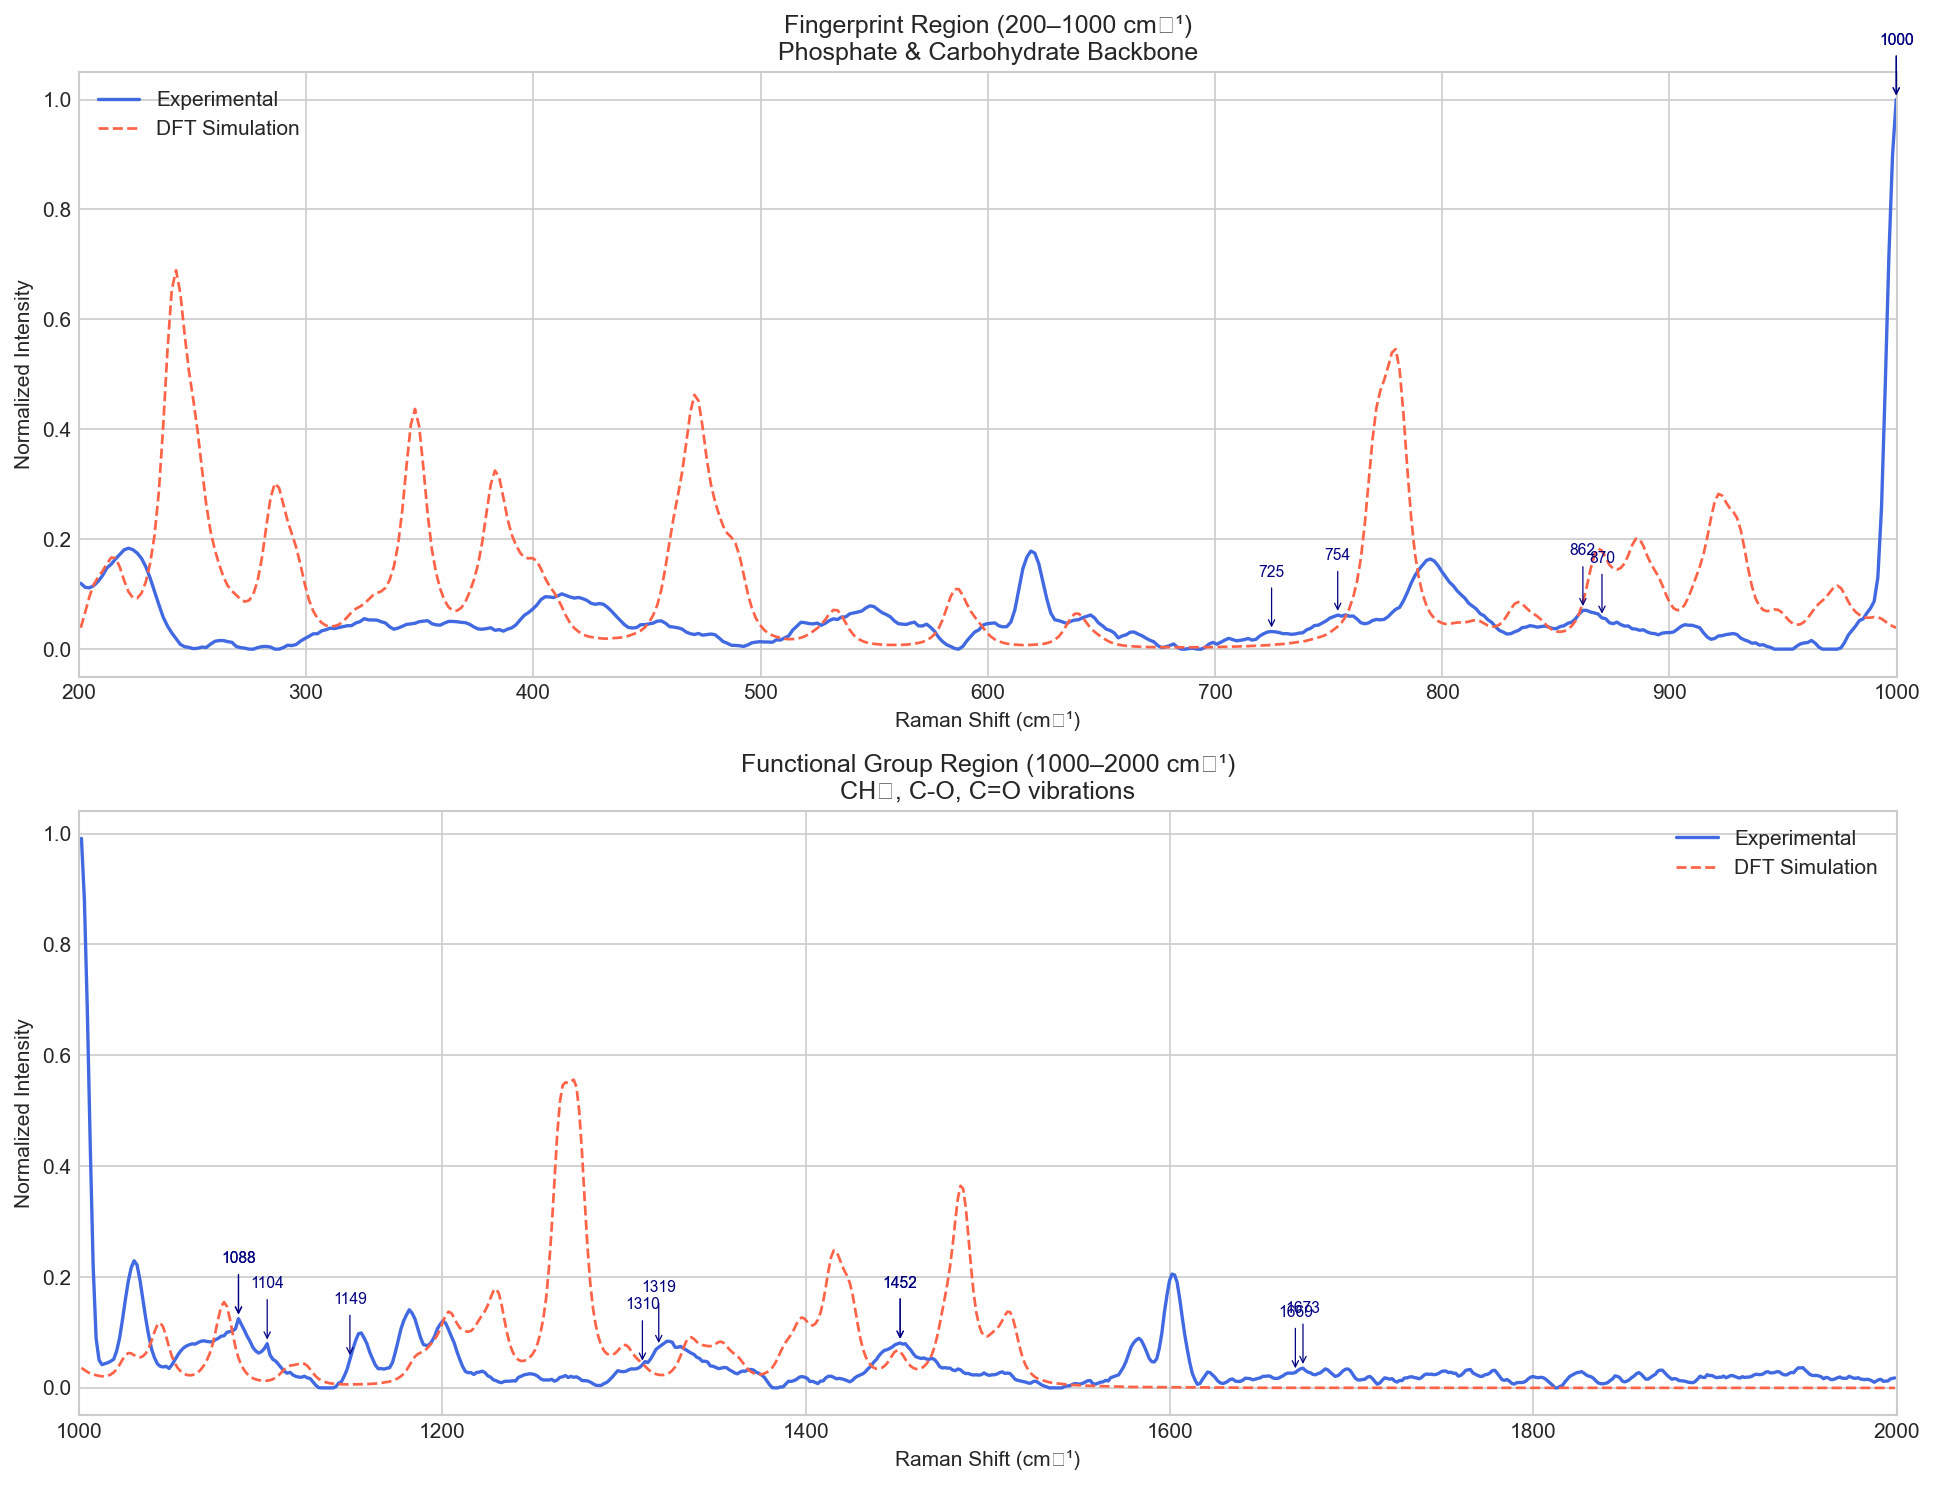

CELL 22 — Figure 12: Region-Split Annotated Spectrum
What was done:
  Split spectrum into two scientifically meaningful regions.
  Top panel: 200–1000 cm⁻¹ (phosphate/carbohydrate fingerprint).
  Bottom panel: 1000–2000 cm⁻¹ (CH₂, C-O, C=O functional groups).
  Annotated peaks in each region.

Saved: fig12_annotated_region_split.png
Status: ✅ Figure 12 saved.


In [21]:
regions = [(200, 1000, 'Fingerprint Region (200–1000 cm⁻¹)\nPhosphate & Carbohydrate Backbone'),
           (1000, 2000, 'Functional Group Region (1000–2000 cm⁻¹)\nCH₂, C-O, C=O vibrations')]

fig, axes = plt.subplots(2, 1, figsize=(13, 10))
for ax, (rmin, rmax, title) in zip(axes, regions):
    mask = (best_x >= rmin) & (best_x <= rmax)
    ax.plot(best_x[mask], best_y[mask], color='royalblue', lw=1.6, label='Experimental')
    if sim_available:
        sim_plot_r = np.interp(best_x[mask], grid, sim_broad)
        ax.plot(best_x[mask], sim_plot_r, color='tomato', lw=1.3, ls='--', label='DFT Simulation')
    for _, row in assign_df.iterrows():
        ep = row['Experimental (cm⁻¹)']
        if np.isnan(ep) or not (rmin <= ep <= rmax): continue
        idx = np.argmin(np.abs(best_x - ep))
        yp  = best_y[idx]
        ax.annotate(f"{ep:.0f}",
                    xy=(ep, yp), xytext=(ep, yp + 0.10),
                    fontsize=7.5, ha='center', color='navy',
                    arrowprops=dict(arrowstyle='->', lw=0.6, color='navy'))
    ax.set_title(title)
    ax.set_xlabel('Raman Shift (cm⁻¹)')
    ax.set_ylabel('Normalized Intensity')
    ax.set_xlim(rmin, rmax)
    ax.legend()

plt.tight_layout()
fig_path = os.path.join(FIG_FOLDER, "fig12_annotated_region_split.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("CELL 22 — Figure 12: Region-Split Annotated Spectrum")
print("=" * 60)
print("What was done:")
print("  Split spectrum into two scientifically meaningful regions.")
print("  Top panel: 200–1000 cm⁻¹ (phosphate/carbohydrate fingerprint).")
print("  Bottom panel: 1000–2000 cm⁻¹ (CH₂, C-O, C=O functional groups).")
print("  Annotated peaks in each region.")
print()
print("Saved: fig12_annotated_region_split.png")
print("Status: ✅ Figure 12 saved.")


In [22]:
from datetime import datetime

peak_list_str = ', '.join([f"{v:.0f}" for v in
                           peak_df['raman_shift'].values]) if len(peak_df) > 0 else "N/A"

report_lines = []
def sec(title): report_lines.extend(["", "=" * 60, title, "=" * 60])
def line(t=""): report_lines.append(t)

report_lines.append("LTA RAMAN ANALYSIS REPORT")
report_lines.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

sec("1. PROJECT INFORMATION")
line(f"  Molecule  : Lipoteichoic Acid (LTA)")
line(f"  Project   : SERS-based Nano-biosensor for Bacterial Sepsis")
line(f"  Institute : IIT Jodhpur")
line(f"  Purpose   : Establish LTA Raman fingerprint for SERS detection")

sec("2. DATASET SUMMARY")
line(f"  Total files processed  : {len(results)}")
line(f"  Integration times      : {unique_sec} sec")
line(f"  Laser powers           : {unique_power} %")
line(f"  Analysis range         : {SHIFT_MIN}–{SHIFT_MAX} cm⁻¹")

sec("3. BEST SPECTRUM SELECTED")
line(f"  Filename           : {best['filename']}")
line(f"  Integration time   : {best['sec']} sec")
line(f"  Laser power        : {best['power']} %")
line(f"  SNR                : {best['snr']:.2f}")
line(f"  FWHM               : {best['fwhm']:.2f} cm⁻¹")
line(f"  Quality Score      : {best['score']:.4f}")

sec("4. EXPERIMENTAL PEAK LIST")
if len(peak_df) > 0:
    for _, r in peak_df.iterrows():
        line(f"  {r['raman_shift']:.1f} cm⁻¹   intensity = {r['intensity']:.4f}")
else:
    line("  No peaks detected.")

sec("5. DFT SIMULATION PARAMETERS")
line(f"  Scaling factor  : {DFT_SCALE}")
line(f"  Gaussian FWHM   : {BROAD_FWHM} cm⁻¹")
if sim_available:
    line(f"  Simulated peaks : {len(sim_filt)}")
else:
    line("  simdata.xlsx not provided — DFT comparison skipped.")

sec("6. PEAK MATCHING RESULTS")
if sim_available and len(match_df) > 0:
    line(f"  Matched peaks   : {match_df['matched'].sum()} / {len(match_df)}")
    line(f"  Mean error      : {mean_err:.2f} cm⁻¹")
    line(f"  RMSE            : {rmse:.2f} cm⁻¹")
    line(f"  Max abs error   : {max_err:.2f} cm⁻¹")
else:
    line("  Skipped.")

sec("7. SPECTRAL SIMILARITY")
if sim_available and not np.isnan(cosine):
    line(f"  Cosine similarity  : {cosine:.4f}")
    line(f"  Pearson correlation: {pearson:.4f}")
    interp = "Excellent" if cosine > 0.9 else ("Good" if cosine > 0.7 else "Moderate")
    line(f"  Interpretation     : {interp} spectral match.")
else:
    line("  Skipped.")

sec("8. PEAK ASSIGNMENTS")
for _, r in assign_df.iterrows():
    line(f"  {r['Nominal (cm⁻¹)']} cm⁻¹  exp={r['Experimental (cm⁻¹)']}  "
         f"sim={r['Simulated (cm⁻¹)']}  Δ={r['Δ (cm⁻¹)']}  {r['Assignment']}")

sec("9. FIGURES GENERATED")
figs = [
    ("fig01", "Acquisition parameter analysis heatmap"),
    ("fig02", "Best spectra annotated overlay"),
    ("fig03", "Experimental vs DFT overlay"),
    ("fig04", "All spectra waterfall"),
    ("fig05", "Score vs laser power"),
    ("fig06", "SNR vs quality score"),
    ("fig07", "Frequency error histogram"),
    ("fig08", "Error vs Raman shift"),
    ("fig09", "Spectral similarity overlay with residual"),
    ("fig10", "4-panel validation summary"),
    ("fig11", "Annotated peak assignment"),
    ("fig12", "Region-split annotated spectrum"),
]
for code, desc in figs:
    line(f"  {code}_*.png  —  {desc}")

sec("10. SCIENTIFIC CONCLUSION")
conclusion = (
    f"The Raman spectrum of Lipoteichoic Acid (LTA) powder recorded at\n"
    f"{best['sec']} s integration time and {best['power']}% laser power exhibited\n"
    f"the highest signal-to-noise ratio ({best['snr']:.1f}) among all {len(results)} spectra analyzed.\n\n"
    f"Major Raman peaks observed at approximately {peak_list_str} cm⁻¹\n"
    f"correspond to P-O-C phosphodiester vibrations, PO₂⁻ symmetric stretching,\n"
    f"CH₂ bending, and C-O-C carbohydrate backbone modes — consistent with\n"
    f"the known vibrational signature of LTA.\n"
)
if sim_available and not np.isnan(cosine):
    conclusion += (
        f"\nComparison with DFT-simulated Raman frequencies (scaled × {DFT_SCALE})\n"
        f"yielded cosine similarity = {cosine:.3f} and Pearson r = {pearson:.3f},\n"
        f"with RMSE = {rmse:.1f} cm⁻¹, confirming good agreement.\n"
    )
conclusion += (
    f"\nThis LTA Raman fingerprint will serve as the reference spectrum\n"
    f"for SERS-based detection in the bacterial sepsis biosensor panel."
)
report_lines.append(conclusion)

report_text = "\n".join(report_lines)
report_path = os.path.join(REPORT_FOLDER, "LTA_analysis_report.txt")
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_text)

print("=" * 60)
print("CELL 23 — Final Report Generated")
print("=" * 60)
print("What was done:")
print("  Built complete scientific report covering all 10 sections.")
print("  Saved to LTA_outputs/report/LTA_analysis_report.txt")
print()
print(f"Report path : {report_path}")
print("Status: ✅ Report saved.")


CELL 23 — Final Report Generated
What was done:
  Built complete scientific report covering all 10 sections.
  Saved to LTA_outputs/report/LTA_analysis_report.txt

Report path : LTA_outputs\report\LTA_analysis_report.txt
Status: ✅ Report saved.


In [23]:
summary_lines = [
    "LTA PROJECT SUMMARY",
    f"Generated : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    "",
    f"Dataset size        : {len(results)} spectra",
    f"Integration times   : {unique_sec} sec",
    f"Laser powers        : {unique_power} %",
    "",
    f"Best Spectrum       : {best['filename']}",
    f"  Integration time  : {best['sec']} sec",
    f"  Laser power       : {best['power']} %",
    f"  SNR               : {best['snr']:.2f}",
    f"  Quality score     : {best['score']:.4f}",
    "",
    f"Main experimental peaks : {peak_list_str} cm⁻¹",
]
if sim_available and not np.isnan(cosine):
    summary_lines += [
        "",
        f"Spectral Similarity",
        f"  Cosine similarity   : {cosine:.4f}",
        f"  Pearson correlation : {pearson:.4f}",
        f"  RMSE                : {rmse:.2f} cm⁻¹",
    ]
summary_lines += [
    "",
    "Output Files Generated:",
    "  Figures   : LTA_outputs/figures/   (12 PNG files)",
    "  Data      : LTA_outputs/data/      (5 CSV files)",
    "  Report    : LTA_outputs/report/LTA_analysis_report.txt",
    "  Summary   : LTA_outputs/report/LTA_project_summary.txt",
]
summary_text = "\n".join(summary_lines)
summary_path = os.path.join(REPORT_FOLDER, "LTA_project_summary.txt")
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary_text)

print("=" * 60)
print("CELL 24 — LTA RAMAN ANALYSIS PIPELINE COMPLETE")
print("=" * 60)
print()
print("FIGURES SAVED:")
figs_info = [
    ("fig01_acquisition_parameter_analysis.png", "Heatmap + SNR + Score + FWHM"),
    ("fig02_best_spectra_annotated.png",          "Top 3 spectra with peak labels"),
    ("fig03_experimental_vs_DFT_overlay.png",     "Experimental vs DFT overlay"),
    ("fig04_all_spectra_waterfall.png",            "All spectra waterfall by power"),
    ("fig05_score_vs_power.png",                   "Score trend vs laser power"),
    ("fig06_SNR_vs_score.png",                     "SNR vs quality score"),
    ("fig07_frequency_error_histogram.png",        "Frequency error histogram"),
    ("fig08_error_vs_raman_shift.png",             "Error vs Raman shift scatter"),
    ("fig09_spectral_similarity_overlay.png",      "Similarity overlay + residual"),
    ("fig10_validation_summary_4panel.png",        "4-panel validation summary"),
    ("fig11_annotated_peak_assignment.png",        "Full annotated peak assignment"),
    ("fig12_annotated_region_split.png",           "Region-split annotated figure"),
]
for fn, desc in figs_info:
    print(f"  {fn}")
    print(f"    → {desc}")
print()
print("DATA FILES SAVED:")
data_files = [
    ("ranked_spectra_table.csv",  "All spectra ranked by quality score"),
    ("peak_matching_table.csv",   "Experimental vs simulated peak match"),
    ("peak_assignment_table.csv", "Functional group assignment table"),
    ("best_spectrum_peaks.csv",   "Detected peaks in best spectrum"),
    ("processed_best_spectrum.csv", "Preprocessed best spectrum data"),
]
for fn, desc in data_files:
    print(f"  {fn}  →  {desc}")
print()
print("REPORTS SAVED:")
print("  LTA_analysis_report.txt  →  Full scientific report")
print("  LTA_project_summary.txt  →  Quick project summary")
print()
print(f"BEST SPECTRUM  : {best['filename']}")
print(f"  Int. Time    : {best['sec']} sec")
print(f"  Laser Power  : {best['power']} %")
print(f"  SNR          : {best['snr']:.2f}")
print(f"  Score        : {best['score']:.4f}")
if sim_available and not np.isnan(cosine):
    print()
    print(f"SPECTRAL VALIDATION:")
    print(f"  Cosine Similarity  : {cosine:.4f}")
    print(f"  Pearson Correlation: {pearson:.4f}")
    print(f"  RMSE               : {rmse:.2f} cm⁻¹")
print()
print("STATUS: ✅ Pipeline complete. All outputs saved to LTA_outputs/")


CELL 24 — LTA RAMAN ANALYSIS PIPELINE COMPLETE

FIGURES SAVED:
  fig01_acquisition_parameter_analysis.png
    → Heatmap + SNR + Score + FWHM
  fig02_best_spectra_annotated.png
    → Top 3 spectra with peak labels
  fig03_experimental_vs_DFT_overlay.png
    → Experimental vs DFT overlay
  fig04_all_spectra_waterfall.png
    → All spectra waterfall by power
  fig05_score_vs_power.png
    → Score trend vs laser power
  fig06_SNR_vs_score.png
    → SNR vs quality score
  fig07_frequency_error_histogram.png
    → Frequency error histogram
  fig08_error_vs_raman_shift.png
    → Error vs Raman shift scatter
  fig09_spectral_similarity_overlay.png
    → Similarity overlay + residual
  fig10_validation_summary_4panel.png
    → 4-panel validation summary
  fig11_annotated_peak_assignment.png
    → Full annotated peak assignment
  fig12_annotated_region_split.png
    → Region-split annotated figure

DATA FILES SAVED:
  ranked_spectra_table.csv  →  All spectra ranked by quality score
  peak_matchi